<a href="https://colab.research.google.com/github/Ahmad986Ferdaws/-SmartInvoice/blob/main/Trained_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EEG-based Movement Intention Classification

This project aims to classify human movement intentions (e.g., 'both_feet', 'both_hands', 'left_hand', 'right_hand') using physiological data, likely Electroencephalography (EEG) or similar brain signals. The classification is performed using a machine learning pipeline that leverages Riemannian geometry for robust signal processing.

## Table of Contents
- [Project Overview](#project-overview)
- [Dataset](#dataset)
- [Prerequisites](#prerequisites)
- [Setup](#setup)
- [Workflow](#workflow)
- [Results and Evaluation](#results-and-evaluation)
- [Outputs](#outputs)

## Project Overview
The core idea is to train a classifier to predict discrete movement intentions based on raw multi-channel time-series data. The pipeline involves data preprocessing, feature extraction using covariance matrices, and classification with Logistic Regression. Cross-validation is used to assess the model's generalization performance.

## Dataset
The dataset consists of NumPy (`.npy`) files organized into:
- `Dataset/Training/`: Contains `X_train_*.npy` (input features - physiological signals) and `y_train_*.npy` (target labels - movement intentions).
- `Dataset/Evaluation/`: Contains `X_eval_*.npy` (unlabeled input features for final prediction).
- `Dataset/Challenge_Dataset/`: Contains additional training and evaluation data for a challenge scenario.

`X` files are expected to have a shape of `(trials, channels, time_points)`, while `y` files contain corresponding labels for each trial.

## Prerequisites
- Python 3.x
- `numpy`
- `scipy`
- `scikit-learn`
- `pyriemann`
- `pandas`
- `matplotlib` (for visualization)

## Setup
It is recommended to use a virtual environment or Google Colab for this project.

### Google Colab
All necessary libraries are installed within the provided Colab notebook. Specific version constraints for `numpy`, `scipy`, and `scikit-learn` are handled to ensure compatibility with `pyriemann`.

```python
!pip -q install -U pip
!pip -q install "numpy<2" "scipy<1.12" "scikit-learn<1.5"
!pip -q install pyriemann
```

### Local Environment
1.  Clone this repository (if applicable).
2.  Install the required packages:
    ```bash
    pip install numpy==1.* scipy==1.11.* scikit-learn==1.4.* pyriemann pandas matplotlib
    ```
    *Note: Specific versions of `numpy`, `scipy`, and `scikit-learn` are crucial for `pyriemann` compatibility.*

## Workflow
The notebook follows these main steps:

1.  **Data Unzipping and Cleaning**: The initial `.zip` archive is extracted, and macOS-specific junk files (`__MACOSX`, `._*`) are removed.
2.  **File Discovery and Pairing**: Training `X` and `y` files are identified and paired based on common numerical indices extracted from their filenames.
3.  **Data Loading**: Paired `X` and `y` data are loaded into NumPy arrays. `y` labels are parsed to ensure consistent string representation.
4.  **Data Cleansing (`cleanse_trials`)**: A custom function is applied to each trial (sample) in `X` data:
    *   Median subtraction.
    *   Normalization by Median Absolute Deviation (MAD).
    *   Clipping values to a specified `clip_sigma` (e.g., 6.0) to reduce outlier impact.
5.  **Label Encoding**: Categorical `y` labels are converted into numerical representations using `sklearn.preprocessing.LabelEncoder`.
6.  **Model Definition**: A `sklearn.pipeline.Pipeline` is constructed:
    *   `pyriemann.estimation.Covariances(estimator="oas")`: Computes covariance matrices from the cleaned EEG signals.
    *   `pyriemann.tangentspace.TangentSpace(metric="riemann")`: Transforms the covariance matrices into a Euclidean space suitable for linear classifiers.
    *   `sklearn.linear_model.LogisticRegression(max_iter=4000, class_weight="balanced")`: A logistic regression classifier to predict movement intentions, with class weighting to handle potential class imbalance.
7.  **Cross-Validation**: `sklearn.model_selection.GroupKFold` is used for robust evaluation. This ensures that trials from the same source (identified by file index, acting as a proxy for 'subject' or 'session') are kept together in either the training or testing set, preventing data leakage. The number of splits is dynamically set to be `min(5, n_groups)`.
8.  **Model Training and Evaluation**: The pipeline is trained and evaluated across folds, reporting accuracy and balanced accuracy. Confusion matrices are generated to provide a detailed view of per-class performance.
9.  **Artifact Report**: A function (`artifact_report`) is provided to inspect data quality both before and after the `cleanse_trials` step, analyzing peak amplitudes, peak-to-peak values, derivatives, and spike fractions.
10. **Final Model Training**: The model is trained on the entire training dataset.
11. **Prediction on Evaluation Data**: The trained model is used to predict labels for the `X_eval_*.npy` files in the `Evaluation` directory. For each evaluation file, a majority vote across its trials determines the final predicted label.

## Results and Evaluation
The cross-validation results provide insights into the model's performance:
- **Mean Accuracy** and **Mean Balanced Accuracy** across folds are reported.
- **Confusion Matrices** (both raw counts and normalized by true class) are visualized to show which classes are frequently confused.
- A **Classification Report** details precision, recall, and F1-score for each class.

Example evaluation metrics from the notebook:
```
Mean acc: 0.2738 ± 0.0395
Mean bal_acc: 0.2738 ± 0.0395

Classification report:
              precision    recall  f1-score   support

   both_feet       0.36      0.10      0.15        84
  both_hands       0.27      0.46      0.34        84
   left_hand       0.26      0.14      0.18        84
  right_hand       0.27      0.39      0.32        84

    accuracy                           0.27       336
   macro avg       0.29      0.27      0.25       336
weighted avg       0.29      0.27      0.25       336
```

## Outputs
- `submission.csv`: A CSV file containing predictions for the evaluation dataset, with columns `id` (corresponding to the `X_eval_*.npy` file index) and `label` (the predicted movement intention).
- `final_eeg_model.joblib`: A serialized Python object containing the trained classification pipeline and the `LabelEncoder` for future use.

In [ ]:
!unzip /content/Dataset.zip

unzip:  cannot find or open /content/Dataset.zip, /content/Dataset.zip.zip or /content/Dataset.zip.ZIP.


In [ ]:
from pathlib import Path
import shutil

ROOT = Path("/content")

# 1) Delete macOS junk folder
mac = ROOT / "__MACOSX"
if mac.exists():
    shutil.rmtree(mac, ignore_errors=True)

# 2) Delete AppleDouble "._" files anywhere
for p in ROOT.rglob("._*"):
    try: p.unlink()
    except: pass

# 3) Optional: delete the zip after extraction (keeps storage clean)
zipf = ROOT / "Dataset.zip"
if zipf.exists():
    zipf.unlink()

print("Done cleaning.")


Done cleaning.


In [ ]:
DATASET = Path("/content/Dataset")
TRAIN_DIR = DATASET / "Training"
EVAL_DIR  = DATASET / "Evaluation"
CHAL_DIR  = DATASET / "Challenge_Dataset"

print("Train exists:", TRAIN_DIR.exists())
print("Eval exists :", EVAL_DIR.exists())
print("Chal exists :", CHAL_DIR.exists())


Train exists: True
Eval exists : False
Chal exists : False


In [ ]:
from collections import Counter
files = [p for p in TRAIN_DIR.rglob("*") if p.is_file()]
print("Total training files:", len(files))
print("Extensions:", Counter([p.suffix.lower() for p in files]))
print("First 10:")
for f in files[:10]:
    print(" -", f.relative_to(TRAIN_DIR))


Total training files: 169
Extensions: Counter({'.npy': 169})
First 10:
 - X_train_79.npy
 - y_train_61.npy
 - X_train_52.npy
 - X_train_51.npy
 - X_train_86.npy
 - X_train_58.npy
 - y_train_62.npy
 - X_train_73.npy
 - y_train_83.npy
 - X_train_18.npy


In [ ]:
import numpy as np
from pathlib import Path
import re

TRAIN_DIR = Path("/content/Dataset/Training")

def idx_from_name(name):
    m = re.search(r"_(\d+)\.npy$", name)
    return int(m.group(1)) if m else None

# pair X and y by index
X_files = {idx_from_name(p.name): p for p in TRAIN_DIR.glob("X_train_*.npy")}
y_files = {idx_from_name(p.name): p for p in TRAIN_DIR.glob("y_train_*.npy")}

common = sorted(set(X_files) & set(y_files))
print("X count:", len(X_files), "y count:", len(y_files), "paired:", len(common))
print("Missing X indices:", sorted(set(y_files) - set(X_files))[:10])
print("Missing y indices:", sorted(set(X_files) - set(y_files))[:10])

# inspect a few pairs
for i in common[:5]:
    X = np.load(X_files[i], allow_pickle=True)
    y = np.load(y_files[i], allow_pickle=True)
    print(f"\nIndex {i}")
    print("  X shape:", getattr(X, "shape", None), "dtype:", getattr(X, "dtype", None))
    print("  y shape:", getattr(y, "shape", None), "dtype:", getattr(y, "dtype", None))
    y_flat = np.array(y).reshape(-1)
    print("  y sample:", y_flat[:5])
    # if X is trial-based, check match
    if hasattr(X, "shape") and len(X.shape) >= 1:
        print("  trials in X:", X.shape[0], "labels:", y_flat.shape[0])


X count: 83 y count: 86 paired: 83
Missing X indices: [54, 67, 70]
Missing y indices: []

Index 1
  X shape: (84, 64, 656) dtype: float64
  y shape: (84,) dtype: (numpy.record, [('limb', 'O')])
  y sample: [('both_feet',) ('right_hand',) ('left_hand',) ('both_hands',)
 ('left_hand',)]
  trials in X: 84 labels: 84

Index 2
  X shape: (90, 64, 656) dtype: float64
  y shape: (90,) dtype: (numpy.record, [('limb', 'O')])
  y sample: [('both_hands',) ('both_hands',) ('both_feet',) ('both_feet',)
 ('right_hand',)]
  trials in X: 90 labels: 90

Index 3
  X shape: (90, 64, 656) dtype: float64
  y shape: (90,) dtype: (numpy.record, [('limb', 'O')])
  y sample: [('both_feet',) ('left_hand',) ('left_hand',) ('both_hands',)
 ('both_feet',)]
  trials in X: 90 labels: 90

Index 4
  X shape: (84, 64, 656) dtype: float64
  y shape: (84,) dtype: (numpy.record, [('limb', 'O')])
  y sample: [('both_feet',) ('both_hands',) ('right_hand',) ('left_hand',)
 ('both_hands',)]
  trials in X: 84 labels: 84

Index

In [ ]:
from pathlib import Path
import re
from collections import Counter

TRAIN_DIR = Path("/content/Dataset/Training")
all_files = [p.name for p in TRAIN_DIR.glob("*.npy")]

print("Total .npy:", len(all_files))
print("First 30 names:")
for n in sorted(all_files)[:30]:
    print(" -", n)

# categorize by prefix
prefix = []
for n in all_files:
    if re.match(r"(?i)^x_train_\d+\.npy$", n): prefix.append("X_train")
    elif re.match(r"(?i)^y_train_\d+\.npy$", n): prefix.append("y_train")
    else: prefix.append("other")

print("Counts:", Counter(prefix))


Total .npy: 169
First 30 names:
 - X_train_1.npy
 - X_train_10.npy
 - X_train_11.npy
 - X_train_12.npy
 - X_train_13.npy
 - X_train_14.npy
 - X_train_15.npy
 - X_train_16.npy
 - X_train_17.npy
 - X_train_18.npy
 - X_train_19.npy
 - X_train_2.npy
 - X_train_20.npy
 - X_train_21.npy
 - X_train_22.npy
 - X_train_23.npy
 - X_train_24.npy
 - X_train_25.npy
 - X_train_26.npy
 - X_train_27.npy
 - X_train_28.npy
 - X_train_29.npy
 - X_train_3.npy
 - X_train_30.npy
 - X_train_31.npy
 - X_train_32.npy
 - X_train_33.npy
 - X_train_34.npy
 - X_train_35.npy
 - X_train_36.npy
Counts: Counter({'y_train': 86, 'X_train': 83})


In [ ]:
import re
from pathlib import Path

TRAIN_DIR = Path("/content/Dataset/Training")

def get_idx(name):
    m = re.search(r"_(\d+)\.npy$", name)
    return int(m.group(1)) if m else None

X_files = {}
y_files = {}

for p in TRAIN_DIR.glob("*.npy"):
    n = p.name
    i = get_idx(n)
    if i is None:
        continue
    if re.match(r"(?i)^x_train_\d+\.npy$", n):   # (?i) = ignore case
        X_files[i] = p
    elif re.match(r"(?i)^y_train_\d+\.npy$", n):
        y_files[i] = p

common = sorted(set(X_files) & set(y_files))
print("X count:", len(X_files), "y count:", len(y_files), "paired:", len(common))
print("Missing X indices:", sorted(set(y_files) - set(X_files))[:20])
print("Missing y indices:", sorted(set(X_files) - set(y_files))[:20])


X count: 83 y count: 86 paired: 83
Missing X indices: [54, 67, 70]
Missing y indices: []


In [ ]:
import numpy as np

def load_y_labels(y_path):
    y = np.load(y_path, allow_pickle=True)

    # structured record array: extract field
    if hasattr(y, "dtype") and y.dtype.fields is not None:
        # common field name is 'limb' from your output
        field = list(y.dtype.fields.keys())[0]
        y = y[field]

    y = np.array(y).reshape(-1)

    # entries look like ('both_feet',) so unwrap tuples
    y = np.array([v[0] if isinstance(v, tuple) and len(v)==1 else v for v in y], dtype=object)

    # bytes -> str if needed
    y = np.array([v.decode() if isinstance(v, (bytes, bytearray)) else v for v in y], dtype=object)

    return y


In [ ]:
!pip -q install pyriemann


In [ ]:
import numpy, scipy, sklearn, sys
print("python:", sys.version)
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("sklearn:", sklearn.__version__)


python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
numpy: 1.26.4
scipy: 1.11.4
sklearn: 1.4.2


In [ ]:
!pip -q install -U pip
!pip -q install "numpy<2" "scipy<1.12" "scikit-learn<1.5"
!pip -q install pyriemann


In [ ]:
import numpy, scipy, sklearn
print(numpy.__version__, scipy.__version__, sklearn.__version__)

try:
    import pyriemann
    from pyriemann.estimation import Covariances
    from pyriemann.tangentspace import TangentSpace
    print("pyriemann OK:", pyriemann.__version__)
except Exception as e:
    print("pyriemann import failed:", repr(e))


1.26.4 1.11.4 1.4.2
pyriemann OK: 0.10


In [ ]:
import numpy as np
import re
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace

TRAIN_DIR = Path("/content/Dataset/Training")

def get_idx(name):
    m = re.search(r"_(\d+)\.npy$", name)
    return int(m.group(1)) if m else None

# discover & pair X/y regardless of case
X_files, y_files = {}, {}
for p in TRAIN_DIR.glob("*.npy"):
    i = get_idx(p.name)
    if i is None:
        continue
    if re.match(r"(?i)^x_train_\d+\.npy$", p.name):
        X_files[i] = p
    elif re.match(r"(?i)^y_train_\d+\.npy$", p.name):
        y_files[i] = p

common = sorted(set(X_files) & set(y_files))
print("X:", len(X_files), "y:", len(y_files), "paired:", len(common))
print("First paired idx:", common[:10])

def load_y_labels(path):
    y = np.load(path, allow_pickle=True)
    # structured record array -> extract field (your field is 'limb')
    if hasattr(y, "dtype") and y.dtype.fields is not None:
        field = list(y.dtype.fields.keys())[0]
        y = y[field]
    y = np.array(y).reshape(-1)
    # unwrap ('both_feet',) tuples
    y = np.array([v[0] if isinstance(v, tuple) and len(v)==1 else v for v in y], dtype=object)
    # bytes -> str
    y = np.array([v.decode() if isinstance(v, (bytes, bytearray)) else v for v in y], dtype=object)
    return y

def cleanse_trials(X, clip_sigma=6.0):
    X = X.astype(np.float32, copy=True)
    med = np.median(X, axis=-1, keepdims=True)
    X = X - med
    mad = np.median(np.abs(X), axis=-1, keepdims=True) + 1e-8
    X = X / mad
    X = np.clip(X, -clip_sigma, clip_sigma)
    return X

# load all
X_list, y_list, g_list = [], [], []
for i in common:
    X = np.load(X_files[i], allow_pickle=True)          # expected (trials, 64, 656)
    y = load_y_labels(y_files[i])                       # strings
    assert X.shape[0] == len(y), f"Mismatch idx={i}: X={X.shape}, y={len(y)}"
    X_list.append(X)
    y_list.append(y)
    g_list.append(np.full(X.shape[0], i))               # group by file index (proxy subject)

X_all = np.concatenate(X_list, axis=0)
y_all = np.concatenate(y_list, axis=0)
g_all = np.concatenate(g_list, axis=0)

print("X_all:", X_all.shape, "y_all:", y_all.shape, "groups:", len(np.unique(g_all)))
print("Unique raw labels:", np.unique(y_all))

# encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y_all)
print("Label mapping:", {i:cls for i,cls in enumerate(le.classes_)})

# cleanse
X_clean = cleanse_trials(X_all, clip_sigma=6.0)

# model
clf = Pipeline([
    ("cov", Covariances(estimator="oas")),
    ("ts", TangentSpace(metric="riemann")),
    ("lr", LogisticRegression(max_iter=4000, class_weight="balanced"))
])

# GroupKFold test
gkf = GroupKFold(n_splits=5)
all_pred = np.zeros_like(y_enc)
accs, baccs = [], []

for fold, (tr, te) in enumerate(gkf.split(X_clean, y_enc, groups=g_all), 1):
    clf.fit(X_clean[tr], y_enc[tr])
    pred = clf.predict(X_clean[te])
    all_pred[te] = pred

    acc = accuracy_score(y_enc[te], pred)
    bacc = balanced_accuracy_score(y_enc[te], pred)
    accs.append(acc); baccs.append(bacc)

    print(f"\nFold {fold} acc={acc:.4f} bal_acc={bacc:.4f}")
    print(confusion_matrix(y_enc[te], pred))

print("\n=== Overall ===")
print("Mean acc:", float(np.mean(accs)), "±", float(np.std(accs)))
print("Mean bal_acc:", float(np.mean(baccs)), "±", float(np.std(baccs)))
print("\nClassification report (all folds combined):")
print(classification_report(y_enc, all_pred, target_names=le.classes_))


X: 83 y: 86 paired: 83
First paired idx: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
X_all: (7087, 64, 656) y_all: (7087,) groups: 83
Unique raw labels: ['both_feet' 'both_hands' 'left_hand' 'right_hand']
Label mapping: {0: 'both_feet', 1: 'both_hands', 2: 'left_hand', 3: 'right_hand'}

Fold 1 acc=0.3595 bal_acc=0.3596
[[109  87  82  88]
 [ 57 126  78  99]
 [ 50  61 137 115]
 [ 44  87  82 150]]

Fold 2 acc=0.3726 bal_acc=0.3727
[[130  92  42  98]
 [ 78 123  48 115]
 [ 53  85 108 118]
 [ 43  75  64 180]]

Fold 3 acc=0.3663 bal_acc=0.3663
[[134  79  71  76]
 [ 74 129  87  68]
 [ 72  77 136  78]
 [ 69  74  92 131]]

Fold 4 acc=0.3545 bal_acc=0.3544
[[160  83  47  54]
 [101 121  52  66]
 [ 99  85  87  71]
 [ 94  79  52 117]]

Fold 5 acc=0.3326 bal_acc=0.3322
[[ 95  57 111  79]
 [ 62  76 129  75]
 [ 51  41 171  82]
 [ 55  37 134 113]]

=== Overall ===
Mean acc: 0.3571006437334396 ± 0.013686607951826494
Mean bal_acc: 0.3570514360986215 ± 0.013859786347956805

Classification report (all folds combined):


In [ ]:
from pathlib import Path
TRAIN_DIR = Path("/content/Dataset/Training")

names = sorted([p.name for p in TRAIN_DIR.glob("*.npy")])
print("Total npy:", len(names))

print("\nFirst 80 filenames:")
for n in names[:80]:
    print(n)

print("\nFilenames containing 'x':")
for n in names:
    if "x" in n.lower():
        print(n)


Total npy: 169

First 80 filenames:
X_train_1.npy
X_train_10.npy
X_train_11.npy
X_train_12.npy
X_train_13.npy
X_train_14.npy
X_train_15.npy
X_train_16.npy
X_train_17.npy
X_train_18.npy
X_train_19.npy
X_train_2.npy
X_train_20.npy
X_train_21.npy
X_train_22.npy
X_train_23.npy
X_train_24.npy
X_train_25.npy
X_train_26.npy
X_train_27.npy
X_train_28.npy
X_train_29.npy
X_train_3.npy
X_train_30.npy
X_train_31.npy
X_train_32.npy
X_train_33.npy
X_train_34.npy
X_train_35.npy
X_train_36.npy
X_train_37.npy
X_train_38.npy
X_train_39.npy
X_train_4.npy
X_train_40.npy
X_train_41.npy
X_train_42.npy
X_train_43.npy
X_train_44.npy
X_train_45.npy
X_train_46.npy
X_train_47.npy
X_train_48.npy
X_train_49.npy
X_train_5.npy
X_train_50.npy
X_train_51.npy
X_train_52.npy
X_train_53.npy
X_train_55.npy
X_train_56.npy
X_train_57.npy
X_train_58.npy
X_train_59.npy
X_train_6.npy
X_train_60.npy
X_train_61.npy
X_train_62.npy
X_train_63.npy
X_train_64.npy
X_train_65.npy
X_train_66.npy
X_train_68.npy
X_train_69.npy
X_train_7.

In [ ]:
import numpy as np
from sklearn.model_selection import GroupKFold

n_groups = len(np.unique(g_all))
gkf = GroupKFold(n_splits=min(5, n_groups))
print("Using n_splits =", min(5, n_groups), "groups =", n_groups)


Using n_splits = 5 groups = 83


In [ ]:
import re
from pathlib import Path

TRAIN_DIR = Path("/content/Dataset/Training")

def idx_from_any(name):
    m = re.search(r"(\d+)\.npy$", name)  # last number before .npy
    return int(m.group(1)) if m else None

X_files, y_files = {}, {}
for p in TRAIN_DIR.glob("*.npy"):
    n = p.name.lower()
    i = idx_from_any(p.name)
    if i is None:
        continue
    if n.startswith("x") and "train" in n and "y" not in n:
        X_files[i] = p
    if n.startswith("y") and "train" in n:
        y_files[i] = p

common = sorted(set(X_files) & set(y_files))
print("X:", len(X_files), "y:", len(y_files), "paired:", len(common))
print("First 20 paired indices:", common[:20])


X: 0 y: 86 paired: 0
First 20 paired indices: []


In [ ]:
print("TRAIN_DIR:", TRAIN_DIR)
print("X files found:", len(X_files))
print("y files found:", len(y_files))
print("common paired indices:", len(common))
print("common sample:", common[:20])

TRAIN_DIR: /content/Dataset/Training
X files found: 0
y files found: 86
common paired indices: 0
common sample: []


In [ ]:
import re
from pathlib import Path

TRAIN_DIR = Path("/content/Dataset/Training")  # adjust if needed

def idx(p):
    return int(re.findall(r"\d+", p.name)[-1])

X_map = {idx(p): p for p in TRAIN_DIR.glob("X_train_*.npy")}
Y_map = {idx(p): p for p in TRAIN_DIR.glob("y_train_*.npy")}

common = sorted(set(X_map) & set(Y_map))

print("X:", len(X_map), "y:", len(Y_map), "paired:", len(common))
print("missing X for y (first 20):", sorted(set(Y_map)-set(X_map))[:20])
print("missing y for X (first 20):", sorted(set(X_map)-set(Y_map))[:20])
print("paired sample:", common[:15])

X: 83 y: 86 paired: 83
missing X for y (first 20): [54, 67, 70]
missing y for X (first 20): []
paired sample: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

def load_y_labels(path):
    y = np.load(path, allow_pickle=True)
    if hasattr(y, "dtype") and y.dtype.fields is not None:
        field = list(y.dtype.fields.keys())[0]  # e.g., 'limb'
        y = y[field]
    y = np.array(y).reshape(-1)
    y = np.array([v[0] if isinstance(v, tuple) and len(v)==1 else v for v in y], dtype=object)
    y = np.array([v.decode() if isinstance(v, (bytes, bytearray)) else v for v in y], dtype=object)
    return y

def cleanse_trials(X, clip_sigma=6.0):
    X = X.astype(np.float32, copy=True)
    X = X - np.median(X, axis=-1, keepdims=True)
    mad = np.median(np.abs(X), axis=-1, keepdims=True) + 1e-8
    X = X / mad
    return np.clip(X, -clip_sigma, clip_sigma)

X_list, y_list, g_list = [], [], []
for i in common:  # <- common from your working pairing cell (paired: 83)
    X = np.load(X_map[i], allow_pickle=True)
    y = load_y_labels(Y_map[i])
    assert X.shape[0] == len(y), (i, X.shape, len(y))
    X_list.append(X)
    y_list.append(y)
    g_list.append(np.full(X.shape[0], i))

X_all = np.concatenate(X_list, axis=0)
y_all = np.concatenate(y_list, axis=0)
g_all = np.concatenate(g_list, axis=0)

le = LabelEncoder()
y_enc = le.fit_transform(y_all)
X_clean = cleanse_trials(X_all)

print("✅ X_clean:", X_clean.shape, "y_enc:", y_enc.shape, "groups:", len(np.unique(g_all)))
print("Classes:", list(le.classes_))

✅ X_clean: (7087, 64, 656) y_enc: (7087,) groups: 83
Classes: ['both_feet', 'both_hands', 'left_hand', 'right_hand']


Fold 1: acc=0.3340  bal_acc=0.3341
Fold 2: acc=0.3602  bal_acc=0.3604
Fold 3: acc=0.3511  bal_acc=0.3510
Fold 4: acc=0.3421  bal_acc=0.3417
Fold 5: acc=0.3121  bal_acc=0.3118

Mean acc: 0.339905164774057 ± 0.016412987935880776
Mean bal_acc: 0.3398008643029763 ± 0.016553564145182595


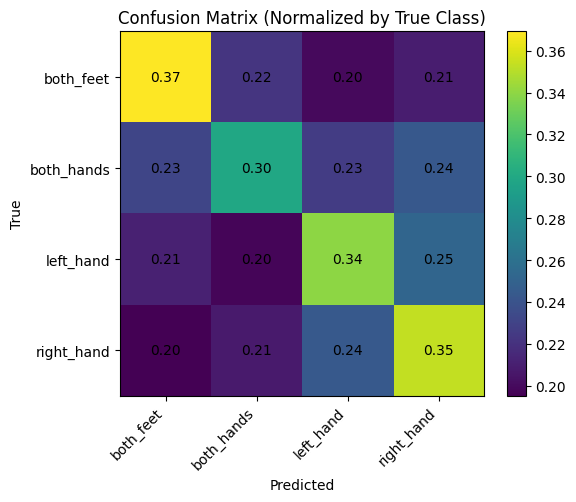


Top 8 confusions (rate, true->pred, count):
0.25  left_hand -> right_hand   (count=448)
0.24  right_hand -> left_hand   (count=432)
0.24  both_hands -> right_hand   (count=429)
0.23  both_hands -> both_feet   (count=409)
0.23  both_hands -> left_hand   (count=399)
0.22  both_feet -> both_hands   (count=394)
0.21  left_hand -> both_feet   (count=375)
0.21  both_feet -> right_hand   (count=371)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix

from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.linear_model import LogisticRegression

# 1) Covariances
cov = Covariances(estimator="scm")
C_all = cov.transform(X_clean)

# 2) CV
n_groups = len(np.unique(g_all))
n_splits = min(5, n_groups)
gkf = GroupKFold(n_splits=n_splits)

all_true = np.zeros_like(y_enc)
all_pred = np.zeros_like(y_enc)

accs, baccs = [], []

for fold, (tr, te) in enumerate(gkf.split(C_all, y_enc, groups=g_all), 1):
    ts = TangentSpace(metric="riemann")
    Xtr = ts.fit_transform(C_all[tr])
    Xte = ts.transform(C_all[te])

    clf = LogisticRegression(max_iter=4000, class_weight="balanced")
    clf.fit(Xtr, y_enc[tr])
    pred = clf.predict(Xte)

    all_true[te] = y_enc[te]
    all_pred[te] = pred

    acc = accuracy_score(y_enc[te], pred)
    bacc = balanced_accuracy_score(y_enc[te], pred)
    accs.append(acc); baccs.append(bacc)
    print(f"Fold {fold}: acc={acc:.4f}  bal_acc={bacc:.4f}")

print("\nMean acc:", float(np.mean(accs)), "±", float(np.std(accs)))
print("Mean bal_acc:", float(np.mean(baccs)), "±", float(np.std(baccs)))

# 3) Confusion matrix (normalized by true class)
cm = confusion_matrix(all_true, all_pred, labels=np.arange(len(le.classes_)))
cmn = cm / (cm.sum(axis=1, keepdims=True) + 1e-12)

plt.figure(figsize=(6,5))
plt.imshow(cmn)
plt.title("Confusion Matrix (Normalized by True Class)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(le.classes_)), le.classes_, rotation=45, ha="right")
plt.yticks(range(len(le.classes_)), le.classes_)
plt.colorbar()

for i in range(cmn.shape[0]):
    for j in range(cmn.shape[1]):
        plt.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

# 4) Top confusions
pairs = []
classes = list(le.classes_)
for i,t in enumerate(classes):
    for j,p in enumerate(classes):
        if i != j:
            pairs.append((cmn[i,j], t, p, cm[i,j]))
pairs.sort(reverse=True)

print("\nTop 8 confusions (rate, true->pred, count):")
for rate, t, p, cnt in pairs[:8]:
    print(f"{rate:.2f}  {t} -> {p}   (count={cnt})")

In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

def load_y_labels(path):
    y = np.load(path, allow_pickle=True)
    if hasattr(y, "dtype") and y.dtype.fields is not None:
        field = list(y.dtype.fields.keys())[0]  # limb
        y = y[field]
    y = np.array(y).reshape(-1)
    y = np.array([v[0] if isinstance(v, tuple) and len(v)==1 else v for v in y], dtype=object)
    y = np.array([v.decode() if isinstance(v, (bytes, bytearray)) else v for v in y], dtype=object)
    return y

def cleanse_trials(X, clip_sigma=6.0):
    X = X.astype(np.float32, copy=True)
    X = X - np.median(X, axis=-1, keepdims=True)
    mad = np.median(np.abs(X), axis=-1, keepdims=True) + 1e-8
    X = X / mad
    return np.clip(X, -clip_sigma, clip_sigma)

X_list, y_list, g_list = [], [], []
for i in common:
    X = np.load(X_files[i], allow_pickle=True)
    y = load_y_labels(y_files[i])
    assert X.shape[0] == len(y), (i, X.shape, len(y))
    X_list.append(X)
    y_list.append(y)
    g_list.append(np.full(X.shape[0], i))

X_all = np.concatenate(X_list, axis=0)
y_all = np.concatenate(y_list, axis=0)
g_all = np.concatenate(g_list, axis=0)

le = LabelEncoder()
y_enc = le.fit_transform(y_all)

X_clean = cleanse_trials(X_all)

print("X_clean:", X_clean.shape, "groups:", len(np.unique(g_all)))
print("Label mapping:", {i:cls for i,cls in enumerate(le.classes_)})


KeyError: 1

In [ ]:
import re
from pathlib import Path
from collections import Counter

TRAIN_DIR = Path("/content/Dataset/Training")

# 1) List files and quick stats
files = sorted([p.name for p in TRAIN_DIR.glob("*.npy")])
print("Total .npy in Training:", len(files))
print("First 40 names:")
for n in files[:40]:
    print(" -", n)

# 2) Robust index extraction: take the LAST number in filename
def extract_idx(name: str):
    nums = re.findall(r"\d+", name)
    return int(nums[-1]) if nums else None

# 3) Robust classification: look for x_train / y_train anywhere (case-insensitive)
X_files, y_files = {}, {}
for p in TRAIN_DIR.glob("*.npy"):
    n = p.name.lower()
    idx = extract_idx(p.name)
    if idx is None:
        continue

    if ("x_train" in n) or (n.startswith("x") and "train" in n and "y_train" not in n):
        X_files[idx] = p
    if ("y_train" in n) or (n.startswith("y") and "train" in n):
        y_files[idx] = p

common = sorted(set(X_files) & set(y_files))

print("\nDetected X files:", len(X_files))
print("Detected y files:", len(y_files))
print("Paired indices:", len(common))
print("First 20 paired:", common[:20])

# 4) If still empty, show what it *did* detect so we can adjust instantly
if len(common) == 0:
    print("\nNo pairs found. Showing 20 candidate X-like names:")
    x_like = [p.name for p in TRAIN_DIR.glob("*.npy") if "x" in p.name.lower()]
    for n in sorted(x_like)[:20]:
        print(" -", n)

    print("\nShowing 20 candidate y-like names:")
    y_like = [p.name for p in TRAIN_DIR.glob("*.npy") if "y" in p.name.lower()]
    for n in sorted(y_like)[:20]:
        print(" -", n)


Total .npy in Training: 169
First 40 names:
 - X_train_1.npy
 - X_train_10.npy
 - X_train_11.npy
 - X_train_12.npy
 - X_train_13.npy
 - X_train_14.npy
 - X_train_15.npy
 - X_train_16.npy
 - X_train_17.npy
 - X_train_18.npy
 - X_train_19.npy
 - X_train_2.npy
 - X_train_20.npy
 - X_train_21.npy
 - X_train_22.npy
 - X_train_23.npy
 - X_train_24.npy
 - X_train_25.npy
 - X_train_26.npy
 - X_train_27.npy
 - X_train_28.npy
 - X_train_29.npy
 - X_train_3.npy
 - X_train_30.npy
 - X_train_31.npy
 - X_train_32.npy
 - X_train_33.npy
 - X_train_34.npy
 - X_train_35.npy
 - X_train_36.npy
 - X_train_37.npy
 - X_train_38.npy
 - X_train_39.npy
 - X_train_4.npy
 - X_train_40.npy
 - X_train_41.npy
 - X_train_42.npy
 - X_train_43.npy
 - X_train_44.npy
 - X_train_45.npy

Detected X files: 83
Detected y files: 86
Paired indices: 83
First 20 paired: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

def load_y_labels(path):
    y = np.load(path, allow_pickle=True)
    if hasattr(y, "dtype") and y.dtype.fields is not None:
        field = list(y.dtype.fields.keys())[0]  # e.g., 'limb'
        y = y[field]
    y = np.array(y).reshape(-1)
    y = np.array([v[0] if isinstance(v, tuple) and len(v)==1 else v for v in y], dtype=object)
    y = np.array([v.decode() if isinstance(v, (bytes, bytearray)) else v for v in y], dtype=object)
    return y

def cleanse_trials(X, clip_sigma=6.0):
    X = X.astype(np.float32, copy=True)
    X = X - np.median(X, axis=-1, keepdims=True)
    mad = np.median(np.abs(X), axis=-1, keepdims=True) + 1e-8
    X = X / mad
    return np.clip(X, -clip_sigma, clip_sigma)

X_list, y_list, g_list = [], [], []
for i in common:
    X = np.load(X_files[i], allow_pickle=True)
    y = load_y_labels(y_files[i])
    assert X.shape[0] == len(y), (i, X.shape, len(y))
    X_list.append(X)
    y_list.append(y)
    g_list.append(np.full(X.shape[0], i))

X_all = np.concatenate(X_list, axis=0)
y_all = np.concatenate(y_list, axis=0)
g_all = np.concatenate(g_list, axis=0)

le = LabelEncoder()
y_enc = le.fit_transform(y_all)
X_clean = cleanse_trials(X_all)

print("X_clean:", X_clean.shape, "groups:", len(np.unique(g_all)))
print("Label mapping:", {i:cls for i,cls in enumerate(le.classes_)})


X_clean: (7087, 64, 656) groups: 83
Label mapping: {0: 'both_feet', 1: 'both_hands', 2: 'left_hand', 3: 'right_hand'}


In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
import numpy as np

clf = Pipeline([
    ("cov", Covariances(estimator="oas")),
    ("ts", TangentSpace(metric="riemann")),
    ("lr", LogisticRegression(max_iter=4000, class_weight="balanced"))
])

n_groups = len(np.unique(g_all))
n_splits = min(5, n_groups)
gkf = GroupKFold(n_splits=n_splits)
print("Groups:", n_groups, "| Using folds:", n_splits)

accs, baccs = [], []
for fold, (tr, te) in enumerate(gkf.split(X_clean, y_enc, groups=g_all), 1):
    clf.fit(X_clean[tr], y_enc[tr])
    pred = clf.predict(X_clean[te])
    acc = accuracy_score(y_enc[te], pred)
    bacc = balanced_accuracy_score(y_enc[te], pred)
    accs.append(acc); baccs.append(bacc)
    print(f"\nFold {fold} acc={acc:.4f} bal_acc={bacc:.4f}")
    print(confusion_matrix(y_enc[te], pred))

print("\nMean acc:", float(np.mean(accs)), "±", float(np.std(accs)))
print("Mean bal_acc:", float(np.mean(baccs)), "±", float(np.std(baccs)))


Groups: 83 | Using folds: 5

Fold 1 acc=0.3595 bal_acc=0.3596
[[109  87  82  88]
 [ 57 126  78  99]
 [ 50  61 137 115]
 [ 44  87  82 150]]

Fold 2 acc=0.3726 bal_acc=0.3727
[[130  92  42  98]
 [ 78 123  48 115]
 [ 53  85 108 118]
 [ 43  75  64 180]]

Fold 3 acc=0.3663 bal_acc=0.3663
[[134  79  71  76]
 [ 74 129  87  68]
 [ 72  77 136  78]
 [ 69  74  92 131]]

Fold 4 acc=0.3545 bal_acc=0.3544
[[160  83  47  54]
 [101 121  52  66]
 [ 99  85  87  71]
 [ 94  79  52 117]]

Fold 5 acc=0.3326 bal_acc=0.3322
[[ 95  57 111  79]
 [ 62  76 129  75]
 [ 51  41 171  82]
 [ 55  37 134 113]]

Mean acc: 0.3571006437334396 ± 0.013686607951826494
Mean bal_acc: 0.3570514360986215 ± 0.013859786347956805


In [ ]:
clf.fit(X_clean, y_enc)
print("Final model trained.")


Final model trained.


In [ ]:

from pathlib import Path
EVAL_DIR = Path("/content/Dataset/Evaluation")
eval_names = sorted([p.name for p in EVAL_DIR.glob("*.npy")])
print("Eval files:", len(eval_names))
print("First 30:", eval_names[:30])


Eval files: 0
First 30: []


In [ ]:
import numpy as np

def artifact_report(X, name="X"):
    # X: (trials, ch, time)
    X = X.astype(np.float32)
    peak = np.max(np.abs(X), axis=(1,2))                  # max abs per trial
    ptp  = np.ptp(X, axis=2).mean(axis=1)                 # mean peak-to-peak across channels per trial
    dX   = np.diff(X, axis=2)
    deriv_peak = np.max(np.abs(dX), axis=(1,2))           # max slope per trial

    # robust z-score spike fraction per trial (using MAD)
    med = np.median(X, axis=2, keepdims=True)
    mad = np.median(np.abs(X - med), axis=2, keepdims=True) + 1e-8
    z = (X - med) / mad
    spike_frac = (np.abs(z) > 6).mean(axis=(1,2))         # fraction of samples beyond 6-MAD

    print(f"\n=== {name} Artifact Report ===")
    print("Trials:", X.shape[0], "Channels:", X.shape[1], "Time:", X.shape[2])
    print("Max|x|  median:", float(np.median(peak)), "  p95:", float(np.percentile(peak,95)), "  max:", float(np.max(peak)))
    print("Mean PTP median:", float(np.median(ptp)), "  p95:", float(np.percentile(ptp,95)))
    print("Max|dx| median:", float(np.median(deriv_peak)), " p95:", float(np.percentile(deriv_peak,95)))
    print("Spike frac (>6 MAD) median:", float(np.median(spike_frac)), " p95:", float(np.percentile(spike_frac,95)))
    return peak, ptp, deriv_peak, spike_frac

# Run both:
artifact_report(X_all, "Raw X_all")
artifact_report(X_clean, "Cleansed X_clean")



=== Raw X_all Artifact Report ===
Trials: 7087 Channels: 64 Time: 656
Max|x|  median: 0.0003150000120513141   p95: 0.0006549999816343188   max: 0.0008099999977275729
Mean PTP median: 0.0002835156046785414   p95: 0.0006040015607140958
Max|dx| median: 0.00018200000340584666  p95: 0.0005559999844990671
Spike frac (>6 MAD) median: 0.005120998475609756  p95: 0.02653391768292683

=== Cleansed X_clean Artifact Report ===
Trials: 7087 Channels: 64 Time: 656
Max|x|  median: 6.0   p95: 6.0   max: 6.0
Mean PTP median: 9.282636642456055   p95: 10.779076194763183
Max|dx| median: 5.473584175109863  p95: 9.898844242095947
Spike frac (>6 MAD) median: 0.005144817073170732  p95: 0.026669683689024386


(array([6., 6., 6., ..., 6., 6., 6.], dtype=float32),
 array([10.074509, 10.214132, 10.531883, ..., 10.240994,  9.474401,
        10.324778], dtype=float32),
 array([ 9.950022 , 10.206995 ,  7.637402 , ...,  6.387226 ,  4.6589017,
         5.9900165], dtype=float32),
 array([0.01102801, 0.02539062, 0.02415206, ..., 0.01464844, 0.01326696,
        0.00828887]))

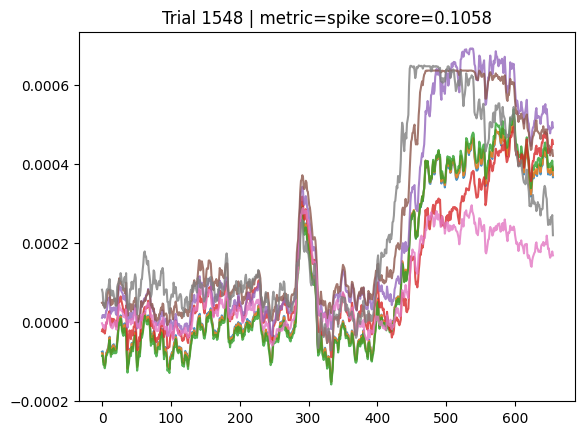

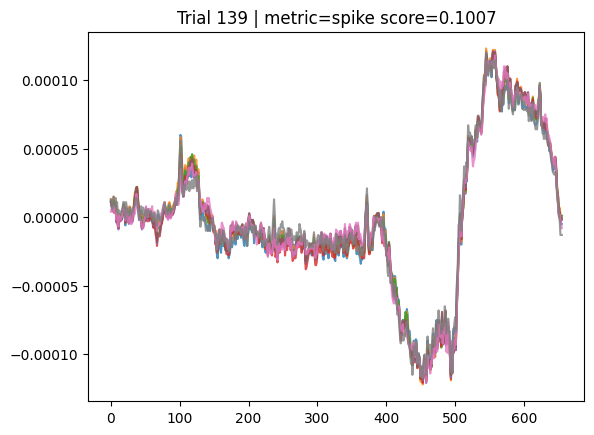

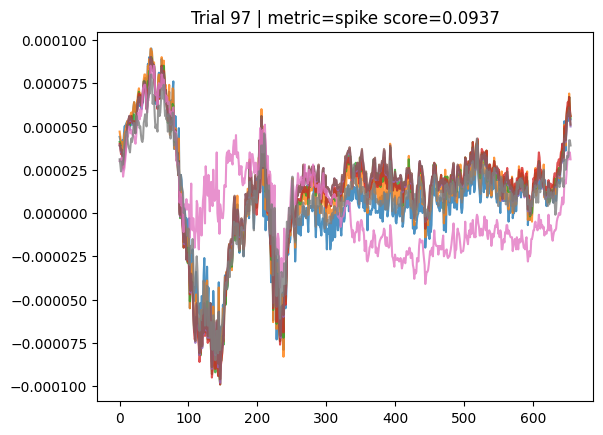

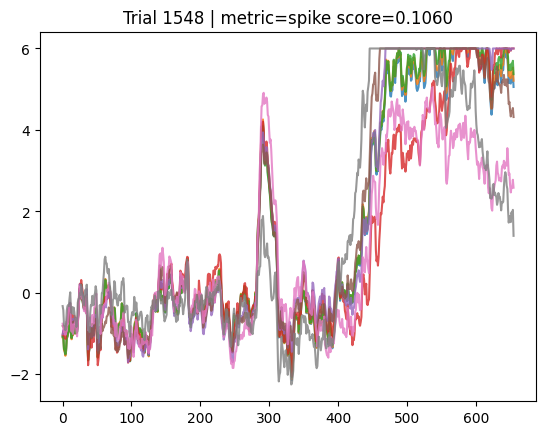

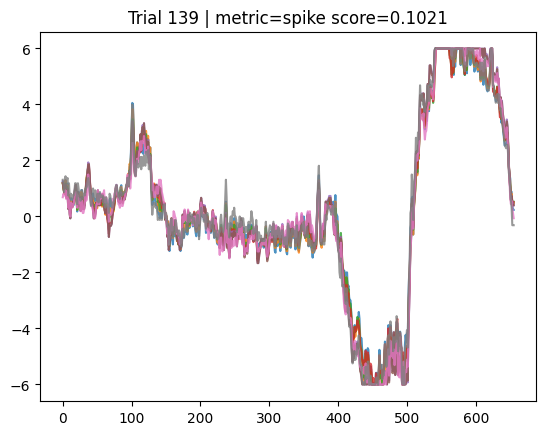

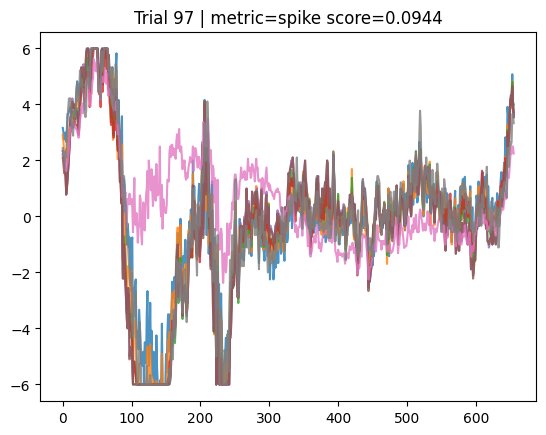

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_worst_trials(X, metric="spike", k=3):
    # metric: "spike" uses >6-MAD fraction, "peak" uses max abs
    X = X.astype(np.float32)
    med = np.median(X, axis=2, keepdims=True)
    mad = np.median(np.abs(X - med), axis=2, keepdims=True) + 1e-8
    z = (X - med) / mad
    spike_frac = (np.abs(z) > 6).mean(axis=(1,2))
    peak = np.max(np.abs(X), axis=(1,2))
    score = spike_frac if metric=="spike" else peak

    idx = np.argsort(score)[::-1][:k]
    for t in idx:
        plt.figure()
        # show a few channels
        for ch in range(min(8, X.shape[1])):
            plt.plot(X[t, ch], alpha=0.8)
        plt.title(f"Trial {t} | metric={metric} score={score[t]:.4f}")
        plt.show()

plot_worst_trials(X_all, metric="spike", k=3)
plot_worst_trials(X_clean, metric="spike", k=3)


In [ ]:
import numpy as np

def spike_scores(X, thresh=6.0):
    # X: (trials, channels, time)
    X = X.astype(np.float32)
    med = np.median(X, axis=2, keepdims=True)
    mad = np.median(np.abs(X - med), axis=2, keepdims=True) + 1e-8
    z = (X - med) / mad
    return (np.abs(z) > thresh).mean(axis=(1,2))  # fraction of extreme samples per trial

scores_raw = spike_scores(X_all)      # or use X_clean if you want after cleaning
count = int((scores_raw > 0.03).sum())
total = scores_raw.shape[0]

print(f"Trials with spike_score > 0.03: {count}/{total} ({count/total*100:.2f}%)")
print("Median:", float(np.median(scores_raw)),
      "P95:", float(np.percentile(scores_raw, 95)),
      "Max:", float(scores_raw.max()))


Trials with spike_score > 0.03: 245/7087 (3.46%)
Median: 0.005120998475609756 P95: 0.02653391768292683 Max: 0.10577839176829268


In [ ]:
from google.colab import files
files.download("submission.csv")


FileNotFoundError: Cannot find file: submission.csv

In [ ]:
import numpy as np, re, joblib
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace

TRAIN_DIR = Path("/content/Dataset/Training")

def extract_idx(name: str):
    nums = re.findall(r"\d+", name)
    return int(nums[-1]) if nums else None

# find X/y files robustly
X_files, y_files = {}, {}
for p in TRAIN_DIR.glob("*.npy"):
    n = p.name.lower()
    idx = extract_idx(p.name)
    if idx is None:
        continue
    if "x_train" in n or (n.startswith("x") and "train" in n and "y_train" not in n):
        X_files[idx] = p
    if "y_train" in n or (n.startswith("y") and "train" in n):
        y_files[idx] = p

common = sorted(set(X_files) & set(y_files))
print("Paired train files:", len(common))

def load_y_labels(path):
    y = np.load(path, allow_pickle=True)
    if hasattr(y, "dtype") and y.dtype.fields is not None:
        field = list(y.dtype.fields.keys())[0]  # e.g. 'limb'
        y = y[field]
    y = np.array(y).reshape(-1)
    y = np.array([v[0] if isinstance(v, tuple) and len(v)==1 else v for v in y], dtype=object)
    y = np.array([v.decode() if isinstance(v, (bytes, bytearray)) else v for v in y], dtype=object)
    return y

def cleanse_trials(X, clip_sigma=6.0):
    X = X.astype(np.float32, copy=True)
    X = X - np.median(X, axis=-1, keepdims=True)
    mad = np.median(np.abs(X), axis=-1, keepdims=True) + 1e-8
    X = X / mad
    return np.clip(X, -clip_sigma, clip_sigma)

# load all training data
X_list, y_list = [], []
for i in common:
    X = np.load(X_files[i], allow_pickle=True)   # (trials, 64, 656)
    y = load_y_labels(y_files[i])                # (trials,)
    assert X.shape[0] == len(y), (i, X.shape, len(y))
    X_list.append(X)
    y_list.append(y)

X_all = np.concatenate(X_list, axis=0)
y_all = np.concatenate(y_list, axis=0)

# encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y_all)

# cleanse
X_clean = cleanse_trials(X_all)

# model
clf = Pipeline([
    ("cov", Covariances(estimator="oas")),
    ("ts", TangentSpace(metric="riemann")),
    ("lr", LogisticRegression(max_iter=4000, class_weight="balanced"))
])

# train final
clf.fit(X_clean, y_enc)
print("Trained on:", X_clean.shape, "| classes:", list(le.classes_))

# save model + encoder
joblib.dump({"model": clf, "label_encoder": le}, "final_eeg_model.joblib")
print("Saved: final_eeg_model.joblib")


Paired train files: 83
Trained on: (7087, 64, 656) | classes: ['both_feet', 'both_hands', 'left_hand', 'right_hand']
Saved: final_eeg_model.joblib


In [ ]:
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace

clf = Pipeline([
    ("cov", Covariances(estimator="oas")),
    ("ts", TangentSpace(metric="riemann")),
    ("lr", LogisticRegression(max_iter=4000, class_weight="balanced"))
])

n_groups = len(np.unique(g_all))
n_splits = min(5, n_groups)
gkf = GroupKFold(n_splits=n_splits)

all_pred = np.zeros_like(y_enc)
accs, baccs = [], []

for fold, (tr, te) in enumerate(gkf.split(X_clean, y_enc, groups=g_all), 1):
    clf.fit(X_clean[tr], y_enc[tr])
    pred = clf.predict(X_clean[te])
    all_pred[te] = pred
    accs.append(accuracy_score(y_enc[te], pred))
    baccs.append(balanced_accuracy_score(y_enc[te], pred))
    print(f"Fold {fold}: acc={accs[-1]:.4f}  bal_acc={baccs[-1]:.4f}")
    print(confusion_matrix(y_enc[te], pred))

print("\nMean acc:", float(np.mean(accs)), "±", float(np.std(accs)))
print("Mean bal_acc:", float(np.mean(baccs)), "±", float(np.std(baccs)))
print("\nReport:")
print(classification_report(y_enc, all_pred, target_names=le.classes_))


Fold 1: acc=0.3595  bal_acc=0.3596
[[109  87  82  88]
 [ 57 126  78  99]
 [ 50  61 137 115]
 [ 44  87  82 150]]
Fold 2: acc=0.3726  bal_acc=0.3727
[[130  92  42  98]
 [ 78 123  48 115]
 [ 53  85 108 118]
 [ 43  75  64 180]]
Fold 3: acc=0.3663  bal_acc=0.3663
[[134  79  71  76]
 [ 74 129  87  68]
 [ 72  77 136  78]
 [ 69  74  92 131]]
Fold 4: acc=0.3545  bal_acc=0.3544
[[160  83  47  54]
 [101 121  52  66]
 [ 99  85  87  71]
 [ 94  79  52 117]]
Fold 5: acc=0.3326  bal_acc=0.3322
[[ 95  57 111  79]
 [ 62  76 129  75]
 [ 51  41 171  82]
 [ 55  37 134 113]]

Mean acc: 0.3571006437334396 ± 0.013686607951826494
Mean bal_acc: 0.3570514360986215 ± 0.013859786347956805

Report:
              precision    recall  f1-score   support

   both_feet       0.39      0.35      0.37      1774
  both_hands       0.34      0.33      0.33      1764
   left_hand       0.35      0.36      0.36      1777
  right_hand       0.35      0.39      0.37      1772

    accuracy                           0.36      7

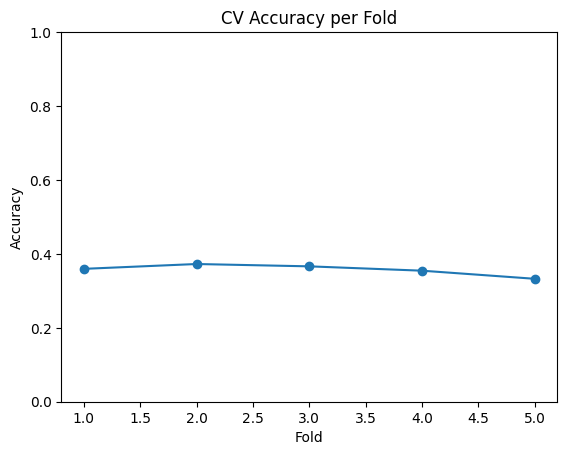

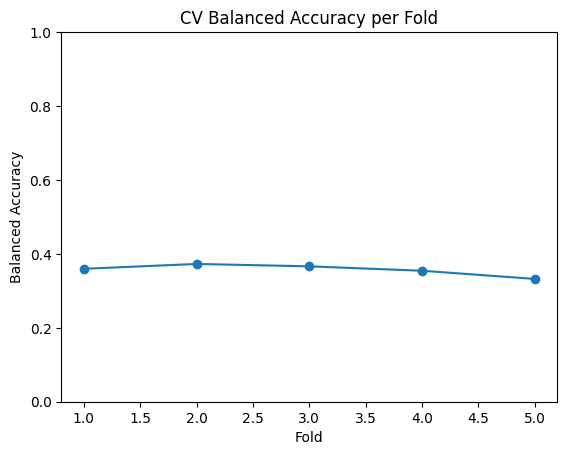

Mean acc: 0.3571006437334396 ± 0.013686607951826494
Mean bal_acc: 0.3570514360986215 ± 0.013859786347956805


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# accs, baccs = lists from your CV loop
x = np.arange(1, len(accs)+1)

plt.figure()
plt.plot(x, accs, marker="o")
plt.title("CV Accuracy per Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

plt.figure()
plt.plot(x, baccs, marker="o")
plt.title("CV Balanced Accuracy per Fold")
plt.xlabel("Fold")
plt.ylabel("Balanced Accuracy")
plt.ylim(0, 1)
plt.show()

print("Mean acc:", float(np.mean(accs)), "±", float(np.std(accs)))
print("Mean bal_acc:", float(np.mean(baccs)), "±", float(np.std(baccs)))


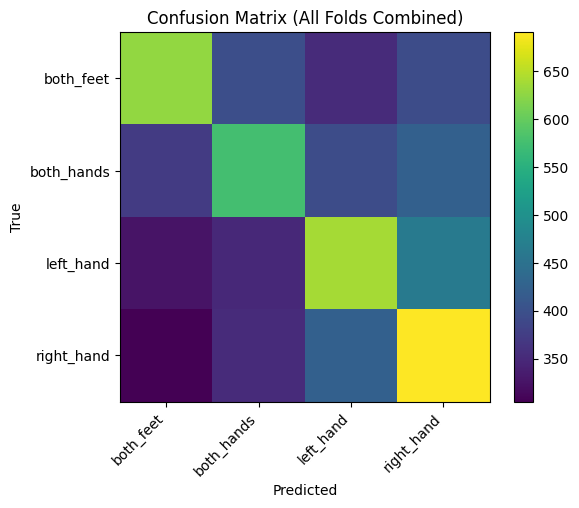

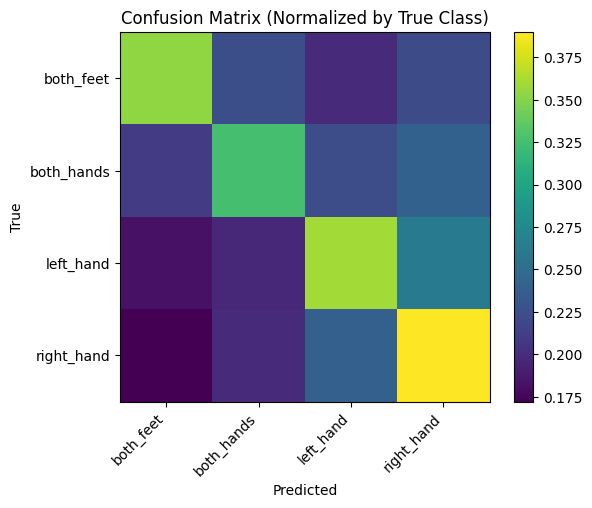

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# If you stored them as concatenated arrays:
# cm = confusion_matrix(all_true, all_pred)
# Otherwise (common in our loop), use:
cm = confusion_matrix(y_enc, all_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (All Folds Combined)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(le.classes_)), le.classes_, rotation=45, ha="right")
plt.yticks(range(len(le.classes_)), le.classes_)
plt.colorbar()
plt.show()

# Normalized (row-wise) version to see % mistakes per true class
cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-12)

plt.figure()
plt.imshow(cm_norm)
plt.title("Confusion Matrix (Normalized by True Class)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(le.classes_)), le.classes_, rotation=45, ha="right")
plt.yticks(range(len(le.classes_)), le.classes_)
plt.colorbar()
plt.show()


In [ ]:
[k for k in globals().keys() if "clf" in k.lower() or "model" in k.lower()]


['clf']

In [ ]:
from sklearn.utils.validation import check_is_fitted

try:
    check_is_fitted(clf)
    print("✅ clf is trained (fitted).")
except Exception as e:
    print("❌ clf is NOT trained yet. Fit it first with clf.fit(...).")
    print("Reason:", e)


✅ clf is trained (fitted).


In [ ]:
pred = clf.predict(X_clean[:5])
print("Predictions:", pred)
print("As labels:", le.inverse_transform(pred))


Predictions: [0 3 2 1 2]
As labels: ['both_feet' 'right_hand' 'left_hand' 'both_hands' 'left_hand']


In [ ]:
lr = clf.named_steps["lr"]
print("Classes:", lr.classes_)
print("Coef shape:", lr.coef_.shape)   # (n_classes, n_features)
print("Intercept shape:", lr.intercept_.shape)


Classes: [0 1 2 3]
Coef shape: (4, 2080)
Intercept shape: (4,)


In [ ]:
# list likely model variables
cands = [k for k in globals().keys() if "clf" in k.lower() or "model" in k.lower()]
print("Candidates:", cands)

# pick the first likely one manually if needed
mname = cands[0]
model = globals()[mname]
print("Using:", mname, "->", type(model))


Candidates: ['clf']
Using: clf -> <class 'sklearn.pipeline.Pipeline'>


In [ ]:
from sklearn.utils.validation import check_is_fitted

check_is_fitted(model)
print("✅ Model is trained (fitted).")

pred = model.predict(X_clean[:5])
print("Pred ints:", pred)
print("Pred labels:", le.inverse_transform(pred))


✅ Model is trained (fitted).
Pred ints: [0 3 2 1 2]
Pred labels: ['both_feet' 'right_hand' 'left_hand' 'both_hands' 'left_hand']


In [ ]:
lr = clf.named_steps["lr"]
print("coef shape:", lr.coef_.shape)  # (4, n_features)
print("intercept:", lr.intercept_)


coef shape: (4, 2080)
intercept: [-0.18881149  0.13294071  0.03901771  0.01685307]


Groups: 83 | Folds: 5
Fold 1: acc=0.3595  bal_acc=0.3596
Fold 2: acc=0.3726  bal_acc=0.3727
Fold 3: acc=0.3663  bal_acc=0.3663
Fold 4: acc=0.3545  bal_acc=0.3544
Fold 5: acc=0.3326  bal_acc=0.3322

Mean acc: 0.3571006437334396 ± 0.013686607951826494
Mean bal_acc: 0.3570514360986215 ± 0.013859786347956805


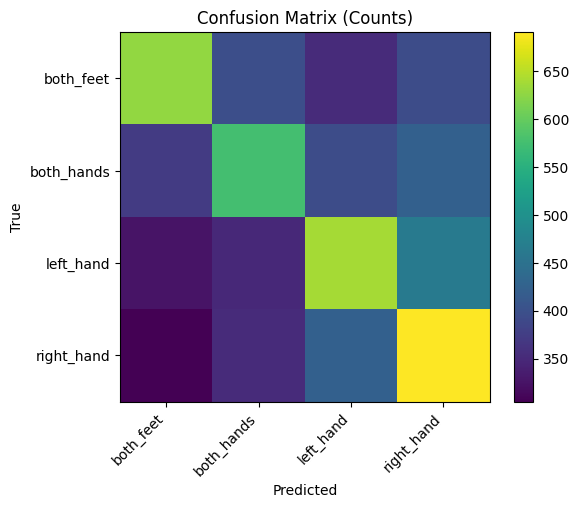

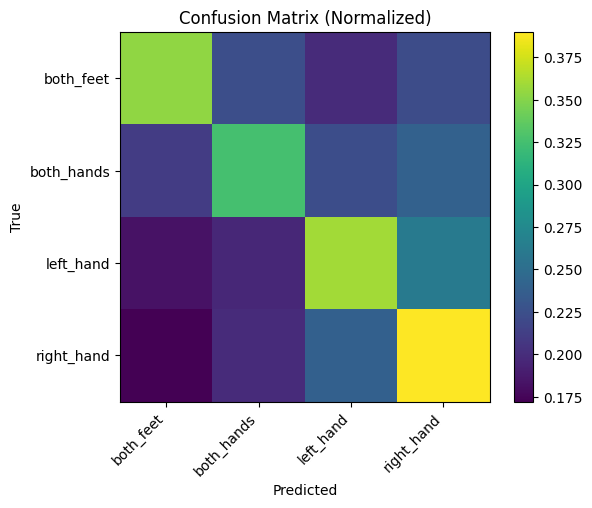


Classification report:
              precision    recall  f1-score   support

   both_feet       0.39      0.35      0.37      1774
  both_hands       0.34      0.33      0.33      1764
   left_hand       0.35      0.36      0.36      1777
  right_hand       0.35      0.39      0.37      1772

    accuracy                           0.36      7087
   macro avg       0.36      0.36      0.36      7087
weighted avg       0.36      0.36      0.36      7087



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report


n_groups = len(np.unique(g_all))
n_splits = min(5, n_groups)
gkf = GroupKFold(n_splits=n_splits)
print("Groups:", n_groups, "| Folds:", n_splits)

accs, baccs = [], []
all_true = np.empty_like(y_enc)
all_pred = np.empty_like(y_enc)

for fold, (tr, te) in enumerate(gkf.split(X_clean, y_enc, groups=g_all), 1):
    clf.fit(X_clean[tr], y_enc[tr])
    pred = clf.predict(X_clean[te])

    all_true[te] = y_enc[te]
    all_pred[te] = pred

    acc = accuracy_score(y_enc[te], pred)
    bacc = balanced_accuracy_score(y_enc[te], pred)
    accs.append(acc); baccs.append(bacc)

    print(f"Fold {fold}: acc={acc:.4f}  bal_acc={bacc:.4f}")

print("\nMean acc:", float(np.mean(accs)), "±", float(np.std(accs)))
print("Mean bal_acc:", float(np.mean(baccs)), "±", float(np.std(baccs)))

# Confusion matrix (counts)
cm = confusion_matrix(all_true, all_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (Counts)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(le.classes_)), le.classes_, rotation=45, ha="right")
plt.yticks(range(len(le.classes_)), le.classes_)
plt.colorbar()
plt.show()

# Confusion matrix (normalized by true class)
cmn = cm / (cm.sum(axis=1, keepdims=True) + 1e-12)

plt.figure()
plt.imshow(cmn)
plt.title("Confusion Matrix (Normalized)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(le.classes_)), le.classes_, rotation=45, ha="right")
plt.yticks(range(len(le.classes_)), le.classes_)
plt.colorbar()
plt.show()

print("\nClassification report:")
print(classification_report(all_true, all_pred, target_names=le.classes_))


In [ ]:
from sklearn.utils.validation import check_is_fitted

try:
    check_is_fitted(clf)
    print("✅ clf is trained (fitted).")
except Exception as e:
    print("❌ clf is NOT trained yet. Fit it first with clf.fit(...).")
    print("Reason:", e)

✅ clf is trained (fitted).


Groups: 83 | Folds: 5
Fold 1: acc=0.3595  bal_acc=0.3596
Fold 2: acc=0.3726  bal_acc=0.3727
Fold 3: acc=0.3663  bal_acc=0.3663
Fold 4: acc=0.3545  bal_acc=0.3544
Fold 5: acc=0.3326  bal_acc=0.3322

Mean acc: 0.3571006437334396 ± 0.013686607951826494
Mean bal_acc: 0.3570514360986215 ± 0.013859786347956805


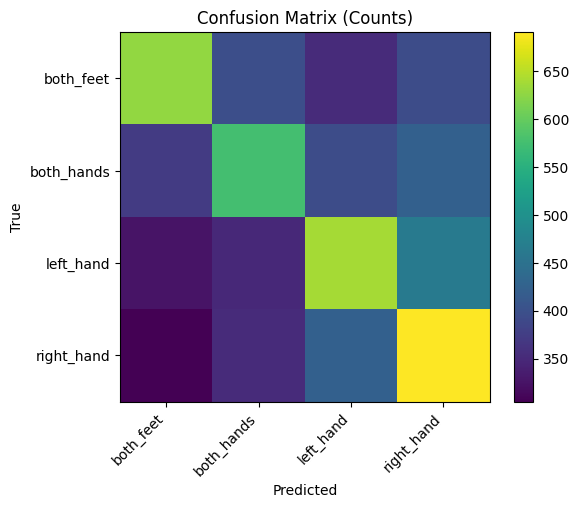

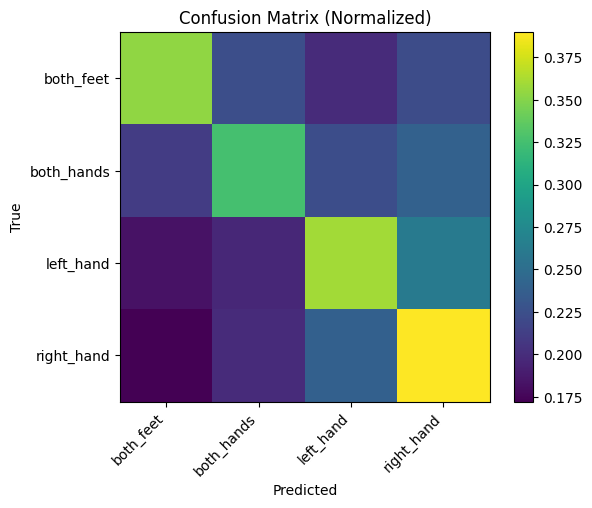


Classification report:
              precision    recall  f1-score   support

   both_feet       0.39      0.35      0.37      1774
  both_hands       0.34      0.33      0.33      1764
   left_hand       0.35      0.36      0.36      1777
  right_hand       0.35      0.39      0.37      1772

    accuracy                           0.36      7087
   macro avg       0.36      0.36      0.36      7087
weighted avg       0.36      0.36      0.36      7087



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report


n_groups = len(np.unique(g_all))
n_splits = min(5, n_groups)
gkf = GroupKFold(n_splits=n_splits)
print("Groups:", n_groups, "| Folds:", n_splits)

accs, baccs = [], []
all_true = np.empty_like(y_enc)
all_pred = np.empty_like(y_enc)

for fold, (tr, te) in enumerate(gkf.split(X_clean, y_enc, groups=g_all), 1):
    clf.fit(X_clean[tr], y_enc[tr])
    pred = clf.predict(X_clean[te])

    all_true[te] = y_enc[te]
    all_pred[te] = pred

    acc = accuracy_score(y_enc[te], pred)
    bacc = balanced_accuracy_score(y_enc[te], pred)
    accs.append(acc); baccs.append(bacc)

    print(f"Fold {fold}: acc={acc:.4f}  bal_acc={bacc:.4f}")

print("\nMean acc:", float(np.mean(accs)), "±", float(np.std(accs)))
print("Mean bal_acc:", float(np.mean(baccs)), "±", float(np.std(baccs)))

# Confusion matrix (counts)
cm = confusion_matrix(all_true, all_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (Counts)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(le.classes_)), le.classes_, rotation=45, ha="right")
plt.yticks(range(len(le.classes_)), le.classes_)
plt.colorbar()
plt.show()

# Confusion matrix (normalized by true class)
cmn = cm / (cm.sum(axis=1, keepdims=True) + 1e-12)

plt.figure()
plt.imshow(cmn)
plt.title("Confusion Matrix (Normalized)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(le.classes_)), le.classes_, rotation=45, ha="right")
plt.yticks(range(len(le.classes_)), le.classes_)
plt.colorbar()
plt.show()

print("\nClassification report:")
print(classification_report(all_true, all_pred, target_names=le.classes_))


In [ ]:
import re
from pathlib import Path

TRAIN_DIR = Path("/content/Dataset/Training")
train_files = sorted([p.name for p in TRAIN_DIR.glob("*.npy")])

print("Total .npy in Training:", len(train_files))
print("Count X_train:", sum("x_train" in n.lower() for n in train_files))
print("Count y_train:", sum("y_train" in n.lower() for n in train_files))

# show first 50 X-like names
x_like = [n for n in train_files if "x" in n.lower()]
print("First 30 x-like:", x_like[:30])


Total .npy in Training: 169
Count X_train: 83
Count y_train: 86
First 30 x-like: ['X_train_1.npy', 'X_train_10.npy', 'X_train_11.npy', 'X_train_12.npy', 'X_train_13.npy', 'X_train_14.npy', 'X_train_15.npy', 'X_train_16.npy', 'X_train_17.npy', 'X_train_18.npy', 'X_train_19.npy', 'X_train_2.npy', 'X_train_20.npy', 'X_train_21.npy', 'X_train_22.npy', 'X_train_23.npy', 'X_train_24.npy', 'X_train_25.npy', 'X_train_26.npy', 'X_train_27.npy', 'X_train_28.npy', 'X_train_29.npy', 'X_train_3.npy', 'X_train_30.npy', 'X_train_31.npy', 'X_train_32.npy', 'X_train_33.npy', 'X_train_34.npy', 'X_train_35.npy', 'X_train_36.npy']


In [ ]:
from pathlib import Path
import re

ROOT = Path("/content")
all_x = sorted(ROOT.rglob("X_train_*.npy"))
all_y = sorted(ROOT.rglob("y_train_*.npy"))

print("Found X_train files:", len(all_x))
print("Found y_train files:", len(all_y))

print("\nSample X paths:")
for p in all_x[:20]:
    print(p)

print("\nSample y paths:")
for p in all_y[:20]:
    print(p)


Found X_train files: 83
Found y_train files: 86

Sample X paths:
/content/Dataset/Training/X_train_1.npy
/content/Dataset/Training/X_train_10.npy
/content/Dataset/Training/X_train_11.npy
/content/Dataset/Training/X_train_12.npy
/content/Dataset/Training/X_train_13.npy
/content/Dataset/Training/X_train_14.npy
/content/Dataset/Training/X_train_15.npy
/content/Dataset/Training/X_train_16.npy
/content/Dataset/Training/X_train_17.npy
/content/Dataset/Training/X_train_18.npy
/content/Dataset/Training/X_train_19.npy
/content/Dataset/Training/X_train_2.npy
/content/Dataset/Training/X_train_20.npy
/content/Dataset/Training/X_train_21.npy
/content/Dataset/Training/X_train_22.npy
/content/Dataset/Training/X_train_23.npy
/content/Dataset/Training/X_train_24.npy
/content/Dataset/Training/X_train_25.npy
/content/Dataset/Training/X_train_26.npy
/content/Dataset/Training/X_train_27.npy

Sample y paths:
/content/Dataset/Training/y_train_1.npy
/content/Dataset/Training/y_train_10.npy
/content/Dataset/Tr

In [ ]:
import re
from pathlib import Path

CH_TRAIN = Path("/content/Dataset/Challenge_Dataset/Training_Challenge")

def idx_last_num(name):
    nums = re.findall(r"\d+", name)
    return int(nums[-1]) if nums else None

X_files, y_files = {}, {}
for p in CH_TRAIN.glob("*.npy"):
    n = p.name.lower()
    idx = idx_last_num(p.name)
    if idx is None:
        continue
    if "x_train_challenge" in n:
        X_files[idx] = p
    if "y_train_challenge" in n:
        y_files[idx] = p

common = sorted(set(X_files) & set(y_files))
print("Challenge train X:", len(X_files), "y:", len(y_files), "paired:", len(common))
print("First 20 paired:", common[:20])


Challenge train X: 0 y: 0 paired: 0
First 20 paired: []


In [ ]:
from pathlib import Path
CH_TRAIN = Path("/content/Dataset/Challenge_Dataset/Training_Challenge")

x = sorted([p.name for p in CH_TRAIN.glob("*.npy") if "x" in p.name.lower()])
y = sorted([p.name for p in CH_TRAIN.glob("*.npy") if "y" in p.name.lower()])

print("X files:", len(x))
print("Y files:", len(y))
print("\nX names:")
for n in x[:50]: print(" ", n)
print("\nY names (first 50):")
for n in y[:50]: print(" ", n)


X files: 0
Y files: 0

X names:

Y names (first 50):


In [ ]:
from pathlib import Path
CH_TRAIN = Path("/content/Dataset/Challenge_Dataset/Training_Challenge")

x = sorted([p.name for p in CH_TRAIN.glob("*.npy") if "x" in p.name.lower()])
y = sorted([p.name for p in CH_TRAIN.glob("*.npy") if "y" in p.name.lower()])

print("X files:", len(x))
print("Y files:", len(y))
print("\nX names:")
for n in x[:50]: print(" ", n)
print("\nY names (first 50):")
for n in y[:50]: print(" ", n)


X files: 0
Y files: 0

X names:

Y names (first 50):


In [ ]:
from pathlib import Path
CH_TRAIN = Path("/content/Dataset/Challenge_Dataset/Training_Challenge")

x = sorted([p.name for p in CH_TRAIN.glob("X_train_challenge_*.npy")])
y = sorted([p.name for p in CH_TRAIN.glob("y_train_challenge_*.npy")])

print("X files:", len(x))
print("Y files:", len(y))
print("X:", x)
print("First 30 Y:", y[:30])


X files: 0
Y files: 0
X: []
First 30 Y: []


In [ ]:
from pathlib import Path
import re

TRAIN_DIR = Path("/content/Dataset/Training")

x_files = sorted(TRAIN_DIR.glob("X_train_*.npy"))
y_files = sorted(TRAIN_DIR.glob("y_train_*.npy"))

print("X_train files:", len(x_files))
print("y_train files:", len(y_files))

# indices
x_idx = sorted(int(re.findall(r"\d+", p.name)[-1]) for p in x_files)
y_idx = sorted(int(re.findall(r"\d+", p.name)[-1]) for p in y_files)

if x_idx:
    print("X idx min/max:", x_idx[0], x_idx[-1])
if y_idx:
    print("y idx min/max:", y_idx[0], y_idx[-1])

paired = sorted(set(x_idx) & set(y_idx))
missing_x = sorted(set(y_idx) - set(x_idx))
missing_y = sorted(set(x_idx) - set(y_idx))

print("Paired (X∩y):", len(paired))
print("Missing X for these y indices (first 30):", missing_x[:30])
print("Missing y for these X indices (first 30):", missing_y[:30])


X_train files: 83
y_train files: 86
X idx min/max: 1 86
y idx min/max: 1 86
Paired (X∩y): 83
Missing X for these y indices (first 30): [54, 67, 70]
Missing y for these X indices (first 30): []


In [ ]:
import numpy as np, re
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace

TRAIN_DIR = Path("/content/Dataset/Training")

def idx(p): return int(re.findall(r"\d+", p.name)[-1])

X_files = {idx(p): p for p in TRAIN_DIR.glob("X_train_*.npy")}
y_files = {idx(p): p for p in TRAIN_DIR.glob("y_train_*.npy")}

common = sorted(set(X_files) & set(y_files))  # exactly the 75 paired indices
print("Paired indices:", len(common), "example:", common[:10])

def load_y_labels(path):
    y = np.load(path, allow_pickle=True)
    if hasattr(y, "dtype") and y.dtype.fields is not None:
        field = list(y.dtype.fields.keys())[0]
        y = y[field]
    y = np.array(y).reshape(-1)
    y = np.array([v[0] if isinstance(v, tuple) and len(v)==1 else v for v in y], dtype=object)
    y = np.array([v.decode() if isinstance(v, (bytes, bytearray)) else v for v in y], dtype=object)
    return y

def cleanse(X, clip=6.0):
    X = X.astype(np.float32, copy=True)
    X = X - np.median(X, axis=-1, keepdims=True)
    mad = np.median(np.abs(X), axis=-1, keepdims=True) + 1e-8
    X = X / mad
    return np.clip(X, -clip, clip)

X_list, y_list, g_list = [], [], []
for i in common:
    X = np.load(X_files[i], allow_pickle=True)
    y = load_y_labels(y_files[i])
    assert X.shape[0] == len(y), (i, X.shape, len(y))
    X_list.append(X); y_list.append(y)
    g_list.append(np.full(X.shape[0], i))

X_all = np.concatenate(X_list, axis=0)
y_all = np.concatenate(y_list, axis=0)
g_all = np.concatenate(g_list, axis=0)

le = LabelEncoder()
y_enc = le.fit_transform(y_all)
X_clean = cleanse(X_all)

clf = Pipeline([
    ("cov", Covariances(estimator="oas")),
    ("ts", TangentSpace(metric="riemann")),
    ("lr", LogisticRegression(max_iter=4000, class_weight="balanced"))
])

n_groups = len(np.unique(g_all))
gkf = GroupKFold(n_splits=5)

accs, baccs = [], []
for fold, (tr, te) in enumerate(gkf.split(X_clean, y_enc, groups=g_all), 1):
    clf.fit(X_clean[tr], y_enc[tr])
    pred = clf.predict(X_clean[te])
    accs.append(accuracy_score(y_enc[te], pred))
    baccs.append(balanced_accuracy_score(y_enc[te], pred))
    print(f"Fold {fold}: acc={accs[-1]:.4f} bal_acc={baccs[-1]:.4f}")

print("\nMean acc:", float(np.mean(accs)), "±", float(np.std(accs)))
print("Mean bal_acc:", float(np.mean(baccs)), "±", float(np.std(baccs)))
print("Classes:", list(le.classes_))


Paired indices: 83 example: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Fold 1: acc=0.3595 bal_acc=0.3596
Fold 2: acc=0.3726 bal_acc=0.3727
Fold 3: acc=0.3663 bal_acc=0.3663
Fold 4: acc=0.3545 bal_acc=0.3544
Fold 5: acc=0.3326 bal_acc=0.3322

Mean acc: 0.3571006437334396 ± 0.013686607951826494
Mean bal_acc: 0.3570514360986215 ± 0.013859786347956805
Classes: ['both_feet', 'both_hands', 'left_hand', 'right_hand']


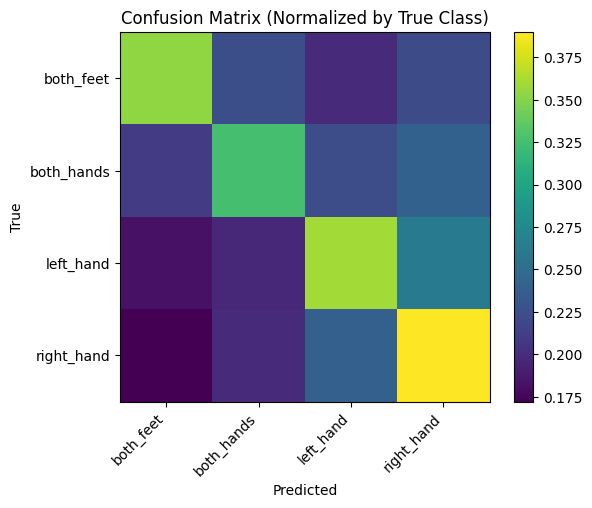

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_true, all_pred)  # from your CV loop
cmn = cm / (cm.sum(axis=1, keepdims=True) + 1e-12)

plt.figure()
plt.imshow(cmn)
plt.title("Confusion Matrix (Normalized by True Class)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(le.classes_)), le.classes_, rotation=45, ha="right")
plt.yticks(range(len(le.classes_)), le.classes_)
plt.colorbar()
plt.show()


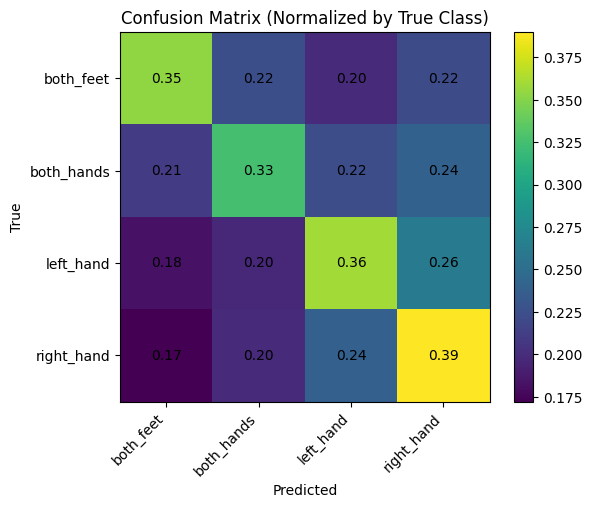

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

cmn = cm / (cm.sum(axis=1, keepdims=True) + 1e-12)
plt.figure()
plt.imshow(cmn)
plt.title("Confusion Matrix (Normalized by True Class)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(range(len(le.classes_)), le.classes_, rotation=45, ha="right")
plt.yticks(range(len(le.classes_)), le.classes_)
plt.colorbar()

for i in range(cmn.shape[0]):
    for j in range(cmn.shape[1]):
        plt.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center")

plt.show()


In [ ]:
recall = np.diag(cmn)
for cls, r in zip(le.classes_, recall):
    print(f"{cls:10s} recall: {r:.3f}")


both_feet  recall: 0.354
both_hands recall: 0.326
left_hand  recall: 0.360
right_hand recall: 0.390


Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done


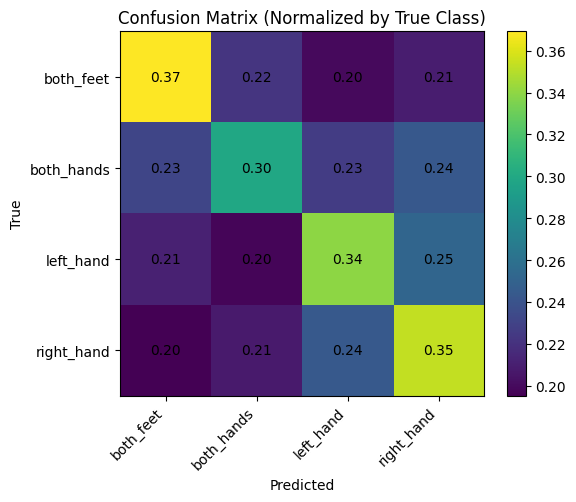

Raw confusion matrix:
 [[655 394 354 371]
 [409 527 399 429]
 [375 351 603 448]
 [346 368 432 626]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.metrics import confusion_matrix
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.linear_model import LogisticRegression

# --- Precompute covariances once (fast) ---
cov = Covariances(estimator="scm")
C_all = cov.transform(X_clean)

# --- CV + collect predictions ---
gkf = GroupKFold(n_splits=5)

all_true = np.zeros_like(y_enc)
all_pred = np.zeros_like(y_enc)

for fold, (tr, te) in enumerate(gkf.split(C_all, y_enc, groups=g_all), 1):
    ts = TangentSpace(metric="riemann")
    Xtr = ts.fit_transform(C_all[tr])
    Xte = ts.transform(C_all[te])

    lr = LogisticRegression(max_iter=4000, class_weight="balanced")
    lr.fit(Xtr, y_enc[tr])
    pred = lr.predict(Xte)

    all_true[te] = y_enc[te]
    all_pred[te] = pred
    print(f"Fold {fold} done")

# --- Confusion matrix (normalized by true class) ---
cm = confusion_matrix(all_true, all_pred, labels=np.arange(len(le.classes_)))
cmn = cm / (cm.sum(axis=1, keepdims=True) + 1e-12)

plt.figure(figsize=(6,5))
plt.imshow(cmn)
plt.title("Confusion Matrix (Normalized by True Class)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(le.classes_)), le.classes_, rotation=45, ha="right")
plt.yticks(range(len(le.classes_)), le.classes_)
plt.colorbar()

# annotate cells
for i in range(cmn.shape[0]):
    for j in range(cmn.shape[1]):
        plt.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

print("Raw confusion matrix:\n", cm)


In [ ]:
import numpy as np

print("Has X_clean?", "X_clean" in globals())
print("Has y_enc?", "y_enc" in globals())
print("Has g_all?", "g_all" in globals())
print("Has le?", "le" in globals())

if "X_clean" in globals():
    print("X_clean shape:", X_clean.shape, "nan:", np.isnan(X_clean).any(), "inf:", np.isinf(X_clean).any())
if "y_enc" in globals():
    print("y_enc shape:", y_enc.shape, "classes:", np.unique(y_enc).size)
if "g_all" in globals():
    print("g_all shape:", g_all.shape, "unique groups:", len(np.unique(g_all)))

Has X_clean? True
Has y_enc? True
Has g_all? True
Has le? True
X_clean shape: (7087, 64, 656) nan: False inf: False
y_enc shape: (7087,) classes: 4
g_all shape: (7087,) unique groups: 83


In [ ]:
import numpy as np, re
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

TRAIN_DIR = Path("/content/Dataset/Training")

def idx(p): return int(re.findall(r"\d+", p.name)[-1])

X_files = {idx(p): p for p in TRAIN_DIR.glob("X_train_*.npy")}
y_files = {idx(p): p for p in TRAIN_DIR.glob("y_train_*.npy")}
common = sorted(set(X_files) & set(y_files))
print("Paired files:", len(common), "example:", common[:10])

def load_y_labels(path):
    y = np.load(path, allow_pickle=True)
    if hasattr(y, "dtype") and y.dtype.fields is not None:
        field = list(y.dtype.fields.keys())[0]
        y = y[field]
    y = np.array(y).reshape(-1)
    y = np.array([v[0] if isinstance(v, tuple) and len(v)==1 else v for v in y], dtype=object)
    y = np.array([v.decode() if isinstance(v, (bytes, bytearray)) else v for v in y], dtype=object)
    return y

def cleanse(X, clip=6.0):
    X = X.astype(np.float32, copy=True)
    X = X - np.median(X, axis=-1, keepdims=True)
    mad = np.median(np.abs(X), axis=-1, keepdims=True) + 1e-8
    X = X / mad
    return np.clip(X, -clip, clip)

X_list, y_list, g_list = [], [], []
for i in common:
    X = np.load(X_files[i], allow_pickle=True)          # (trials, 64, 656)
    y = load_y_labels(y_files[i])                       # (trials,)
    assert X.shape[0] == len(y), (i, X.shape, len(y))
    X_list.append(X)
    y_list.append(y)
    g_list.append(np.full(X.shape[0], i))

X_all = np.concatenate(X_list, axis=0)
y_all = np.concatenate(y_list, axis=0)
g_all = np.concatenate(g_list, axis=0)

le = LabelEncoder()
y_enc = le.fit_transform(y_all)
X_clean = cleanse(X_all)

print("X_clean:", X_clean.shape, "y_enc:", y_enc.shape, "groups:", len(np.unique(g_all)))
print("Classes:", list(le.classes_))

Paired files: 83 example: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
X_clean: (7087, 64, 656) y_enc: (7087,) groups: 83
Classes: ['both_feet', 'both_hands', 'left_hand', 'right_hand']


In [ ]:
from pathlib import Path
TRAIN_DIR = Path("/content/Dataset/Training")

print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("Files in TRAIN_DIR:", len(list(TRAIN_DIR.glob("*"))))

x = list(TRAIN_DIR.glob("X_train_*.npy"))
y = list(TRAIN_DIR.glob("y_train_*.npy"))
print("X_train count:", len(x))
print("y_train count:", len(y))

if len(x) > 0: print("Example X:", x[0].name)
if len(y) > 0: print("Example y:", y[0].name)

TRAIN_DIR exists: True
Files in TRAIN_DIR: 169
X_train count: 83
y_train count: 86
Example X: X_train_79.npy
Example y: y_train_61.npy


In [ ]:
from pathlib import Path

root = Path("/content")
hits = []

for p in root.rglob("X_train_*.npy"):
    hits.append(p.parent)

hits = sorted(set(hits))
print("Folders containing X_train_*.npy:", len(hits))
for h in hits[:30]:
    print(h)

Folders containing X_train_*.npy: 1
/content/Dataset/Training


In [ ]:
TRAIN_DIR = Path("PASTE_THE_FOLDER_FROM_OUTPUT_HERE")

In [ ]:
from pathlib import Path

TRAIN_DIR = Path("/content/Dataset/Training")
print("TRAIN_DIR exists:", TRAIN_DIR.exists())

if TRAIN_DIR.exists():
    files = list(TRAIN_DIR.glob("*"))
    print("Files currently in Training:", len(files))
    print("First 15:", [p.name for p in sorted(files)[:15]])
    print("X_train count:", len(list(TRAIN_DIR.glob("X_train_*.npy"))))
    print("y_train count:", len(list(TRAIN_DIR.glob("y_train_*.npy"))))
else:
    # maybe it's in /content directly right after upload
    print("Top of /content:", [p.name for p in sorted(Path('/content').glob('*'))][:30])

TRAIN_DIR exists: True
Files currently in Training: 169
First 15: ['X_train_1.npy', 'X_train_10.npy', 'X_train_11.npy', 'X_train_12.npy', 'X_train_13.npy', 'X_train_14.npy', 'X_train_15.npy', 'X_train_16.npy', 'X_train_17.npy', 'X_train_18.npy', 'X_train_19.npy', 'X_train_2.npy', 'X_train_20.npy', 'X_train_21.npy', 'X_train_22.npy']
X_train count: 83
y_train count: 86


In [ ]:
from pathlib import Path
root = Path("/content")
print("X_train:", len(list(root.glob("X_train_*.npy"))))
print("y_train:", len(list(root.glob("y_train_*.npy"))))

X_train: 0
y_train: 0


In [ ]:
from pathlib import Path
import shutil

root = Path("/content")
dst = root / "Dataset" / "Training"
dst.mkdir(parents=True, exist_ok=True)

moved = 0
for p in root.glob("X_train_*.npy"):
    shutil.move(str(p), str(dst / p.name)); moved += 1
for p in root.glob("y_train_*.npy"):
    shutil.move(str(p), str(dst / p.name)); moved += 1

print("Moved files:", moved)
print("Now in Training:",
      "X =", len(list(dst.glob("X_train_*.npy"))),
      "y =", len(list(dst.glob("y_train_*.npy"))))

Moved files: 0
Now in Training: X = 83 y = 86


In [ ]:
from pathlib import Path

root = Path("/content")
x = list(root.rglob("X_train_*.npy"))
y = list(root.rglob("y_train_*.npy"))

print("FOUND X_train:", len(x))
print("FOUND y_train:", len(y))

# show where they are (top 10)
for p in x[:10]:
    print("X example:", p)
for p in y[:10]:
    print("y example:", p)

FOUND X_train: 83
FOUND y_train: 86
X example: /content/Dataset/Training/X_train_79.npy
X example: /content/Dataset/Training/X_train_52.npy
X example: /content/Dataset/Training/X_train_51.npy
X example: /content/Dataset/Training/X_train_86.npy
X example: /content/Dataset/Training/X_train_58.npy
X example: /content/Dataset/Training/X_train_73.npy
X example: /content/Dataset/Training/X_train_18.npy
X example: /content/Dataset/Training/X_train_48.npy
X example: /content/Dataset/Training/X_train_8.npy
X example: /content/Dataset/Training/X_train_25.npy
y example: /content/Dataset/Training/y_train_61.npy
y example: /content/Dataset/Training/y_train_62.npy
y example: /content/Dataset/Training/y_train_83.npy
y example: /content/Dataset/Training/y_train_8.npy
y example: /content/Dataset/Training/y_train_13.npy
y example: /content/Dataset/Training/y_train_65.npy
y example: /content/Dataset/Training/y_train_48.npy
y example: /content/Dataset/Training/y_train_40.npy
y example: /content/Dataset/Tr

In [ ]:
from pathlib import Path
import shutil

root = Path("/content")
dst = root / "Dataset" / "Training"
dst.mkdir(parents=True, exist_ok=True)

x = list(root.rglob("X_train_*.npy"))
y = list(root.rglob("y_train_*.npy"))

moved = 0
for p in x:
    if p.parent != dst:
        shutil.move(str(p), str(dst / p.name)); moved += 1
for p in y:
    if p.parent != dst:
        shutil.move(str(p), str(dst / p.name)); moved += 1

print("Moved:", moved)
print("Now in /content/Dataset/Training:",
      "X =", len(list(dst.glob("X_train_*.npy"))),
      "y =", len(list(dst.glob("y_train_*.npy"))))

Moved: 0
Now in /content/Dataset/Training: X = 83 y = 86


In [ ]:
from pathlib import Path
import re

TRAIN_DIR = Path("/content/Dataset/Training")

def idx(name):
    return int(re.findall(r"\d+", name)[-1])

x_files = sorted(TRAIN_DIR.glob("X_train_*.npy"))
y_files = sorted(TRAIN_DIR.glob("y_train_*.npy"))

x_idx = sorted(idx(p.name) for p in x_files)
y_idx = sorted(idx(p.name) for p in y_files)

paired = sorted(set(x_idx) & set(y_idx))
missing_x = sorted(set(y_idx) - set(x_idx))
missing_y = sorted(set(x_idx) - set(y_idx))

print("X count:", len(x_idx), "Y count:", len(y_idx), "Paired:", len(paired))
print("Missing X for these y indices:", missing_x)
print("Missing y for these X indices:", missing_y)

print("Example paired:", paired[:20])

X count: 83 Y count: 86 Paired: 83
Missing X for these y indices: [54, 67, 70]
Missing y for these X indices: []
Example paired: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


In [ ]:
from sklearn.utils.validation import check_is_fitted

cands = [k for k in globals().keys() if "clf" in k.lower() or "model" in k.lower()]
print("Model-like variables:", cands)

for name in cands:
    obj = globals()[name]
    try:
        check_is_fitted(obj)
        print(f"✅ {name} is FITTED ({type(obj)})")
    except Exception as e:
        print(f"❌ {name} not fitted / not a sklearn estimator ({type(obj)})")

Model-like variables: ['clf', 'model']
✅ clf is FITTED (<class 'sklearn.pipeline.Pipeline'>)
✅ model is FITTED (<class 'sklearn.pipeline.Pipeline'>)


In [ ]:
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.linear_model import LogisticRegression

cov = Covariances(estimator="scm")
C_all = cov.transform(X_clean)

gkf = GroupKFold(n_splits=5)
accs, baccs = [], []

for fold,(tr,te) in enumerate(gkf.split(C_all, y_enc, groups=g_all),1):
    ts = TangentSpace(metric="riemann")
    Xtr = ts.fit_transform(C_all[tr])
    Xte = ts.transform(C_all[te])

    clf = LogisticRegression(max_iter=4000, class_weight="balanced")
    clf.fit(Xtr, y_enc[tr])
    pred = clf.predict(Xte)

    accs.append(accuracy_score(y_enc[te], pred))
    baccs.append(balanced_accuracy_score(y_enc[te], pred))
    print(f"Fold {fold}: acc={accs[-1]:.4f}  bal_acc={baccs[-1]:.4f}")

print("\nMean acc:", float(np.mean(accs)), "±", float(np.std(accs)))
print("Mean bal_acc:", float(np.mean(baccs)), "±", float(np.std(baccs)))

Fold 1: acc=0.3340  bal_acc=0.3341
Fold 2: acc=0.3602  bal_acc=0.3604
Fold 3: acc=0.3511  bal_acc=0.3510
Fold 4: acc=0.3421  bal_acc=0.3417
Fold 5: acc=0.3121  bal_acc=0.3118

Mean acc: 0.339905164774057 ± 0.016412987935880776
Mean bal_acc: 0.3398008643029763 ± 0.016553564145182595


Computing covariances...

Groups: 83 | Folds: 5

Fold 1: acc=0.3340  bal_acc=0.3341  n_test=1452
Fold 2: acc=0.3602  bal_acc=0.3604  n_test=1452
Fold 3: acc=0.3511  bal_acc=0.3510  n_test=1447
Fold 4: acc=0.3421  bal_acc=0.3417  n_test=1368
Fold 5: acc=0.3121  bal_acc=0.3118  n_test=1368

=== Overall CV ===
Mean acc: 0.339905164774057 ± 0.016412987935880776
Mean bal_acc: 0.3398008643029763 ± 0.016553564145182595

=== Classification report (OOF) ===
              precision    recall  f1-score   support

   both_feet     0.3669    0.3692    0.3681      1774
  both_hands     0.3213    0.2988    0.3096      1764
   left_hand     0.3372    0.3393    0.3383      1777
  right_hand     0.3340    0.3533    0.3434      1772

    accuracy                         0.3402      7087
   macro avg     0.3399    0.3401    0.3398      7087
weighted avg     0.3399    0.3402    0.3399      7087



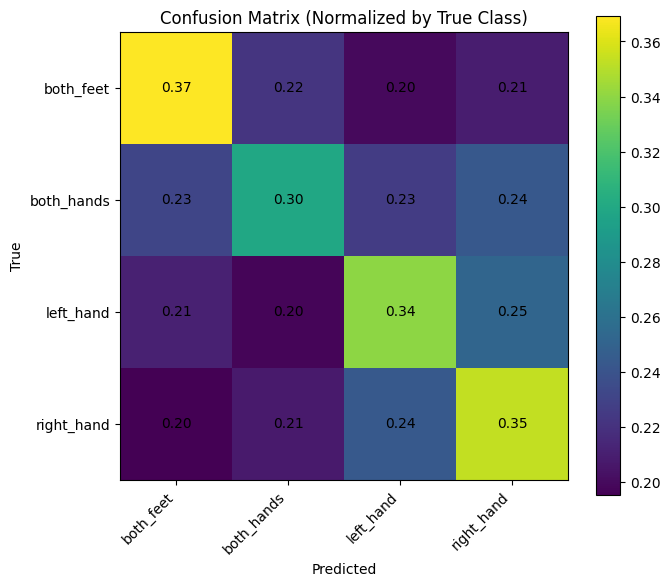


=== Top 10 confusions (rate, true->pred, count) ===
0.25  left_hand -> right_hand   (count=448)
0.24  right_hand -> left_hand   (count=432)
0.24  both_hands -> right_hand   (count=429)
0.23  both_hands -> both_feet   (count=409)
0.23  both_hands -> left_hand   (count=399)
0.22  both_feet -> both_hands   (count=394)
0.21  left_hand -> both_feet   (count=375)
0.21  both_feet -> right_hand   (count=371)
0.21  right_hand -> both_hands   (count=368)
0.20  both_feet -> left_hand   (count=354)

=== Confidence stats ===
Median confidence: 0.9461089968681335
P10/P90: 0.5953899025917053 / 0.9996661186218262
Min/Max: 0.28488680720329285 / 1.0
Low-confidence rate (<0.40): 0.55%


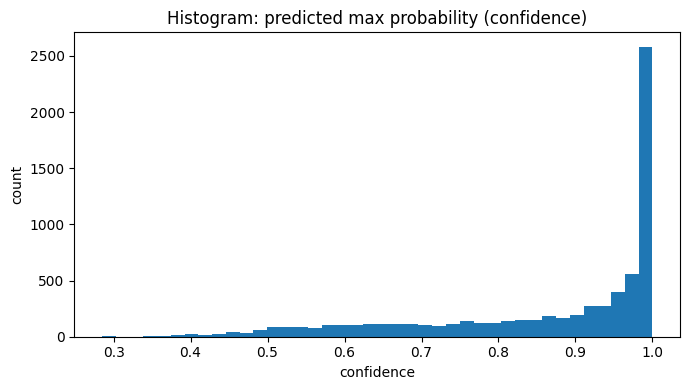


=== 20 most uncertain samples (lowest confidence) ===
idx= 3596  conf=0.285  true=right_hand  pred=right_hand  proba=[0.23541512 0.2473036  0.23239446 0.2848868 ]
idx= 1941  conf=0.296  true=right_hand  pred=both_feet   proba=[0.29593313 0.27443862 0.15507069 0.27455756]
idx= 4076  conf=0.305  true=both_feet   pred=left_hand   proba=[0.20837373 0.24388377 0.30493227 0.24281025]
idx= 3382  conf=0.344  true=both_hands  pred=both_feet   proba=[0.3443087  0.31509262 0.01590053 0.32469812]
idx= 2441  conf=0.349  true=right_hand  pred=right_hand  proba=[0.14670336 0.20337068 0.30134258 0.3485834 ]
idx= 3993  conf=0.350  true=both_hands  pred=left_hand   proba=[0.00562683 0.34063944 0.34972826 0.30400547]
idx= 6423  conf=0.350  true=left_hand   pred=both_feet   proba=[0.34980944 0.300518   0.18146743 0.16820514]
idx= 5842  conf=0.352  true=right_hand  pred=both_hands  proba=[1.9524411e-04 3.5153919e-01 3.4318835e-01 3.0507722e-01]
idx= 3642  conf=0.352  true=both_hands  pred=both_hands  prob

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    confusion_matrix, classification_report
)

from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.linear_model import LogisticRegression

# ---------------------------
# 0) Sanity checks
# ---------------------------
assert "X_clean" in globals() and "y_enc" in globals() and "g_all" in globals() and "le" in globals(), \
    "Missing variables. Make sure X_clean, y_enc, g_all, le exist."

classes = list(le.classes_)
n_classes = len(classes)

# ---------------------------
# 1) Precompute covariances
# ---------------------------
print("Computing covariances...")
cov = Covariances(estimator="scm")
C_all = cov.transform(X_clean)  # shape: (n_trials, ch, ch)

# ---------------------------
# 2) GroupKFold CV (out-of-fold predictions)
# ---------------------------
n_groups = len(np.unique(g_all))
n_splits = min(5, n_groups)
assert n_splits >= 2, f"Need >=2 groups. You have {n_groups}."

gkf = GroupKFold(n_splits=n_splits)

all_true = np.zeros_like(y_enc)
all_pred = np.zeros_like(y_enc)
all_proba = np.zeros((len(y_enc), n_classes), dtype=np.float32)

accs, baccs = [], []

print(f"\nGroups: {n_groups} | Folds: {n_splits}\n")

for fold, (tr, te) in enumerate(gkf.split(C_all, y_enc, groups=g_all), 1):
    ts = TangentSpace(metric="riemann")

    Xtr = ts.fit_transform(C_all[tr])
    Xte = ts.transform(C_all[te])

    clf = LogisticRegression(
        max_iter=6000,
        class_weight="balanced",
        n_jobs=None
    )
    clf.fit(Xtr, y_enc[tr])

    pred = clf.predict(Xte)
    proba = clf.predict_proba(Xte)

    all_true[te] = y_enc[te]
    all_pred[te] = pred
    all_proba[te] = proba

    acc = accuracy_score(y_enc[te], pred)
    bacc = balanced_accuracy_score(y_enc[te], pred)
    accs.append(acc); baccs.append(bacc)
    print(f"Fold {fold}: acc={acc:.4f}  bal_acc={bacc:.4f}  n_test={len(te)}")

print("\n=== Overall CV ===")
print("Mean acc:", float(np.mean(accs)), "±", float(np.std(accs)))
print("Mean bal_acc:", float(np.mean(baccs)), "±", float(np.std(baccs)))

# ---------------------------
# 3) Classification report
# ---------------------------
print("\n=== Classification report (OOF) ===")
print(classification_report(all_true, all_pred, target_names=classes, digits=4))

# ---------------------------
# 4) Confusion matrix (normalized by true class)
# ---------------------------
cm = confusion_matrix(all_true, all_pred, labels=np.arange(n_classes))
cmn = cm / (cm.sum(axis=1, keepdims=True) + 1e-12)

plt.figure(figsize=(7,6))
plt.imshow(cmn)
plt.title("Confusion Matrix (Normalized by True Class)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(n_classes), classes, rotation=45, ha="right")
plt.yticks(range(n_classes), classes)
plt.colorbar()

for i in range(n_classes):
    for j in range(n_classes):
        plt.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

# ---------------------------
# 5) Top confusions
# ---------------------------
pairs = []
for i, t in enumerate(classes):
    for j, p in enumerate(classes):
        if i != j:
            pairs.append((cmn[i, j], t, p, cm[i, j]))
pairs.sort(reverse=True)

print("\n=== Top 10 confusions (rate, true->pred, count) ===")
for rate, t, p, cnt in pairs[:10]:
    print(f"{rate:.2f}  {t} -> {p}   (count={cnt})")

# ---------------------------
# 6) Confidence analysis
# ---------------------------
conf = all_proba.max(axis=1)
pred_label = all_proba.argmax(axis=1)

print("\n=== Confidence stats ===")
print("Median confidence:", float(np.median(conf)))
print("P10/P90:", float(np.percentile(conf, 10)), "/", float(np.percentile(conf, 90)))
print("Min/Max:", float(conf.min()), "/", float(conf.max()))

low_thr = 0.40
low_rate = float((conf < low_thr).mean())
print(f"Low-confidence rate (<{low_thr:.2f}): {low_rate*100:.2f}%")

plt.figure(figsize=(7,4))
plt.hist(conf, bins=40)
plt.title("Histogram: predicted max probability (confidence)")
plt.xlabel("confidence")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# ---------------------------
# 7) Show most uncertain samples (useful for debugging)
# ---------------------------
k = 20
unc_idx = np.argsort(conf)[:k]
print(f"\n=== {k} most uncertain samples (lowest confidence) ===")
for ii in unc_idx:
    t = classes[all_true[ii]]
    p = classes[all_pred[ii]]
    print(f"idx={ii:5d}  conf={conf[ii]:.3f}  true={t:10s}  pred={p:10s}  proba={all_proba[ii]}")

In [ ]:
from pathlib import Path

root = Path("/content")
# search common docs
docs = []
for ext in ["*.txt","*.md","*.csv","*.json","*.yaml","*.yml"]:
    docs += list(root.rglob(ext))

print("Found docs:", len(docs))
hits = []
keywords = ["sfreq", "sampling", "sample rate", "hz", "BCI2000", "fs"]
for p in docs:
    try:
        txt = p.read_text(errors="ignore").lower()
        if any(k in txt for k in keywords):
            hits.append(p)
    except:
        pass

print("Docs containing sampling keywords:", len(hits))
for p in hits[:25]:
    print(" -", p)

# if we found some, show a few lines around "hz"/"sampling"
for p in hits[:5]:
    txt = p.read_text(errors="ignore").splitlines()
    print("\n===== ", p, " =====")
    for i,line in enumerate(txt):
        low = line.lower()
        if any(k in low for k in keywords):
            start = max(0, i-3); end = min(len(txt), i+4)
            for j in range(start, end):
                print(txt[j])
            break

Found docs: 9
Docs containing sampling keywords: 0


In [ ]:
import numpy as np
from scipy.signal import welch

# Use a small subset to keep it fast
rng = np.random.default_rng(0)
n_trials = X_clean.shape[0]
pick = rng.choice(n_trials, size=min(80, n_trials), replace=False)

# average PSD across a few channels to stabilize
ch_pick = np.linspace(0, X_clean.shape[1]-1, 8, dtype=int)

Xsub = X_clean[pick][:, ch_pick, :]  # (trials, ch, time)

def line_peak_score(fs, target=60.0, bw=1.0):
    # Welch PSD per trial/channel; average
    # Output: relative energy around target Hz compared to broad band
    psd_acc = None
    for t in range(Xsub.shape[0]):
        for c in range(Xsub.shape[1]):
            f, p = welch(Xsub[t, c], fs=fs, nperseg=min(256, Xsub.shape[-1]))
            if psd_acc is None:
                psd_acc = p.copy()
                f_ref = f
            else:
                psd_acc += p
    psd_acc /= (Xsub.shape[0] * Xsub.shape[1])

    band = (f_ref >= 1) & (f_ref <= min(100, fs/2 - 1))
    peak = (f_ref >= target-bw) & (f_ref <= target+bw)
    if peak.sum() == 0:
        return 0.0
    return float(psd_acc[peak].mean() / (psd_acc[band].mean() + 1e-12))

candidates = [128, 160, 200, 250, 256, 320, 512]
rows = []
for fs in candidates:
    s60 = line_peak_score(fs, 60.0, bw=1.0)
    s50 = line_peak_score(fs, 50.0, bw=1.0)
    rows.append((fs, s60, s50))

rows_sorted = sorted(rows, key=lambda x: max(x[1], x[2]), reverse=True)

print("Sampling-rate candidates ranked by strongest line-noise peak:")
for fs, s60, s50 in rows_sorted:
    best = "60Hz" if s60 >= s50 else "50Hz"
    print(f"fs={fs:>3d} Hz | score@60={s60:.3f}  score@50={s50:.3f}  -> best={best}")

best_fs = rows_sorted[0][0]
print("\nSuggested fs:", best_fs, "Hz")

Sampling-rate candidates ranked by strongest line-noise peak:
fs=160 Hz | score@60=2.917  score@50=0.210  -> best=60Hz
fs=512 Hz | score@60=0.264  score@50=0.304  -> best=50Hz
fs=200 Hz | score@60=0.236  score@50=0.276  -> best=50Hz
fs=320 Hz | score@60=0.214  score@50=0.260  -> best=50Hz
fs=250 Hz | score@60=0.224  score@50=0.250  -> best=50Hz
fs=256 Hz | score@60=0.183  score@50=0.207  -> best=50Hz
fs=128 Hz | score@60=0.090  score@50=0.129  -> best=50Hz

Suggested fs: 160 Hz


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt

from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace

fs = 160  # inferred
bands = [
    ("theta", 4, 8),
    ("mu",    8, 12),
    ("beta",  13, 30),
    ("gamma", 30, 45),
]

def bandpass_sos(low, high, fs, order=4):
    nyq = fs / 2
    low = max(low, 0.5)
    high = min(high, nyq - 1e-3)
    return butter(order, [low/nyq, high/nyq], btype="bandpass", output="sos")

def compute_band_covariances(X, fs, bands, chunk=256):
    """
    X: (trials, channels, time) float32/float64
    returns: dict band_name -> covs array (trials, ch, ch) float32
    """
    X = X.astype(np.float32, copy=False)
    n_trials, n_ch, n_t = X.shape
    cov = Covariances(estimator="scm")

    out = {}
    for name, lo, hi in bands:
        print(f"\nComputing covariances for band {name} [{lo}-{hi}] Hz ...")
        sos = bandpass_sos(lo, hi, fs, order=4)
        C = np.empty((n_trials, n_ch, n_ch), dtype=np.float32)

        for s in range(0, n_trials, chunk):
            e = min(n_trials, s+chunk)
            Xb = sosfiltfilt(sos, X[s:e], axis=-1)  # (chunk, ch, time)
            C[s:e] = cov.transform(Xb).astype(np.float32)
        out[name] = C
        print(f"  done: {C.shape}")
    return out

# 1) Precompute band covariances
band_covs = compute_band_covariances(X_clean, fs, bands, chunk=256)

# 2) CV
n_groups = len(np.unique(g_all))
n_splits = min(5, n_groups)
gkf = GroupKFold(n_splits=n_splits)

all_true = np.zeros_like(y_enc)
all_pred = np.zeros_like(y_enc)

accs, baccs = [], []

for fold, (tr, te) in enumerate(gkf.split(X_clean, y_enc, groups=g_all), 1):
    Xtr_feats = []
    Xte_feats = []

    # Tangent space per band, then concatenate features
    for name, _, _ in bands:
        ts = TangentSpace(metric="riemann")
        Xtr_feats.append(ts.fit_transform(band_covs[name][tr]))
        Xte_feats.append(ts.transform(band_covs[name][te]))

    Xtr = np.concatenate(Xtr_feats, axis=1)
    Xte = np.concatenate(Xte_feats, axis=1)

    clf = LogisticRegression(max_iter=6000, class_weight="balanced")
    clf.fit(Xtr, y_enc[tr])
    pred = clf.predict(Xte)

    all_true[te] = y_enc[te]
    all_pred[te] = pred

    acc = accuracy_score(y_enc[te], pred)
    bacc = balanced_accuracy_score(y_enc[te], pred)
    accs.append(acc); baccs.append(bacc)
    print(f"Fold {fold}: acc={acc:.4f}  bal_acc={bacc:.4f}  n_test={len(te)}")

print("\n=== Overall CV (Filter-bank Riemann) ===")
print("Mean acc:", float(np.mean(accs)), "±", float(np.std(accs)))
print("Mean bal_acc:", float(np.mean(baccs)), "±", float(np.std(baccs)))

# 3) Confusion matrix (normalized)
classes = list(le.classes_)
cm = confusion_matrix(all_true, all_pred, labels=np.arange(len(classes)))
cmn = cm / (cm.sum(axis=1, keepdims=True) + 1e-12)

plt.figure(figsize=(7,6))
plt.imshow(cmn)
plt.title("Confusion Matrix (Normalized by True Class) — Filter-bank Riemann")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(range(len(classes)), classes, rotation=45, ha="right")
plt.yticks(range(len(classes)), classes)
plt.colorbar()
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center")
plt.tight_layout()
plt.show()

# 4) Top confusions
pairs = []
for i,t in enumerate(classes):
    for j,p in enumerate(classes):
        if i != j:
            pairs.append((cmn[i,j], t, p, cm[i,j]))
pairs.sort(reverse=True)
print("\nTop 8 confusions (rate, true->pred, count):")
for rate, t, p, cnt in pairs[:8]:
    print(f"{rate:.2f}  {t} -> {p}   (count={cnt})")


Computing covariances for band theta [4-8] Hz ...
  done: (7087, 64, 64)

Computing covariances for band mu [8-12] Hz ...
  done: (7087, 64, 64)

Computing covariances for band beta [13-30] Hz ...
  done: (7087, 64, 64)

Computing covariances for band gamma [30-45] Hz ...
  done: (7087, 64, 64)


/usr/local/lib/python3.12/dist-packages/pyriemann/utils/base.py:60: RuntimeWarning: invalid value encountered in log
  eigvals = operator(eigvals)


ValueError: Matrices must be positive definite. You should add regularization to avoid this error.


Band theta [4-8] Hz ...
  done: (7087, 64, 64)

Band mu [8-12] Hz ...
  done: (7087, 64, 64)

Band beta [13-30] Hz ...
  done: (7087, 64, 64)

Band gamma [30-45] Hz ...
  done: (7087, 64, 64)
Fold 1: acc=0.4208  bal_acc=0.4207
Fold 2: acc=0.4208  bal_acc=0.4209
Fold 3: acc=0.4236  bal_acc=0.4236
Fold 4: acc=0.4510  bal_acc=0.4510
Fold 5: acc=0.4115  bal_acc=0.4113

=== Overall CV (Filter-bank Riemann + OAS) ===
Mean acc: 0.4255612005353262 ± 0.013369472721302641
Mean bal_acc: 0.4254996667125213 ± 0.013403311211929506


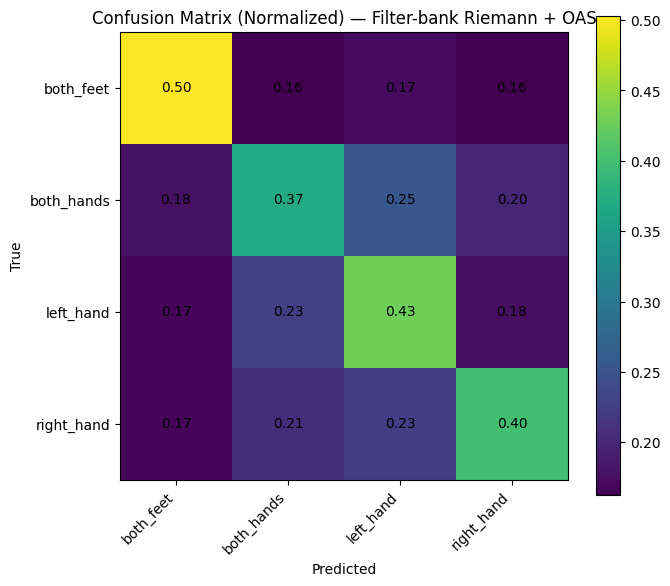


Top 8 confusions (rate, true->pred, count):
0.25  both_hands -> left_hand   (count=448)
0.23  left_hand -> both_hands   (count=403)
0.23  right_hand -> left_hand   (count=400)
0.21  right_hand -> both_hands   (count=366)
0.20  both_hands -> right_hand   (count=349)
0.18  both_hands -> both_feet   (count=313)
0.18  left_hand -> right_hand   (count=313)
0.17  both_feet -> left_hand   (count=306)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt

from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace

fs = 160
bands = [
    ("theta", 4, 8),
    ("mu",    8, 12),
    ("beta",  13, 30),
    ("gamma", 30, 45),
]

def bandpass_sos(low, high, fs, order=4):
    nyq = fs / 2
    low = max(low, 0.5)
    high = min(high, nyq - 1e-3)
    return butter(order, [low/nyq, high/nyq], btype="bandpass", output="sos")

def compute_band_covariances(X, fs, bands, chunk=256):
    X = X.astype(np.float32, copy=False)
    n_trials, n_ch, _ = X.shape

    # ✅ regularized covariance (fix SPD issue)
    cov = Covariances(estimator="oas")

    out = {}
    for name, lo, hi in bands:
        print(f"\nBand {name} [{lo}-{hi}] Hz ...")
        sos = bandpass_sos(lo, hi, fs, order=4)
        C = np.empty((n_trials, n_ch, n_ch), dtype=np.float32)

        for s in range(0, n_trials, chunk):
            e = min(n_trials, s+chunk)
            Xb = sosfiltfilt(sos, X[s:e], axis=-1)
            C[s:e] = cov.transform(Xb).astype(np.float32)

        out[name] = C
        print("  done:", C.shape)
    return out

band_covs = compute_band_covariances(X_clean, fs, bands, chunk=256)

n_groups = len(np.unique(g_all))
n_splits = min(5, n_groups)
gkf = GroupKFold(n_splits=n_splits)

all_true = np.zeros_like(y_enc)
all_pred = np.zeros_like(y_enc)

accs, baccs = [], []

for fold, (tr, te) in enumerate(gkf.split(X_clean, y_enc, groups=g_all), 1):
    Xtr_feats, Xte_feats = [], []

    for name, _, _ in bands:
        ts = TangentSpace(metric="riemann")
        Xtr_feats.append(ts.fit_transform(band_covs[name][tr]))
        Xte_feats.append(ts.transform(band_covs[name][te]))

    Xtr = np.concatenate(Xtr_feats, axis=1)
    Xte = np.concatenate(Xte_feats, axis=1)

    clf = LogisticRegression(max_iter=6000, class_weight="balanced")
    clf.fit(Xtr, y_enc[tr])
    pred = clf.predict(Xte)

    all_true[te] = y_enc[te]
    all_pred[te] = pred

    acc = accuracy_score(y_enc[te], pred)
    bacc = balanced_accuracy_score(y_enc[te], pred)
    accs.append(acc); baccs.append(bacc)
    print(f"Fold {fold}: acc={acc:.4f}  bal_acc={bacc:.4f}")

print("\n=== Overall CV (Filter-bank Riemann + OAS) ===")
print("Mean acc:", float(np.mean(accs)), "±", float(np.std(accs)))
print("Mean bal_acc:", float(np.mean(baccs)), "±", float(np.std(baccs)))

classes = list(le.classes_)
cm = confusion_matrix(all_true, all_pred, labels=np.arange(len(classes)))
cmn = cm / (cm.sum(axis=1, keepdims=True) + 1e-12)

plt.figure(figsize=(7,6))
plt.imshow(cmn)
plt.title("Confusion Matrix (Normalized) — Filter-bank Riemann + OAS")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(range(len(classes)), classes, rotation=45, ha="right")
plt.yticks(range(len(classes)), classes)
plt.colorbar()
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center")
plt.tight_layout()
plt.show()

pairs = []
for i,t in enumerate(classes):
    for j,p in enumerate(classes):
        if i != j:
            pairs.append((cmn[i,j], t, p, cm[i,j]))
pairs.sort(reverse=True)

print("\nTop 8 confusions (rate, true->pred, count):")
for rate, t, p, cnt in pairs[:8]:
    print(f"{rate:.2f}  {t} -> {p}   (count={cnt})")

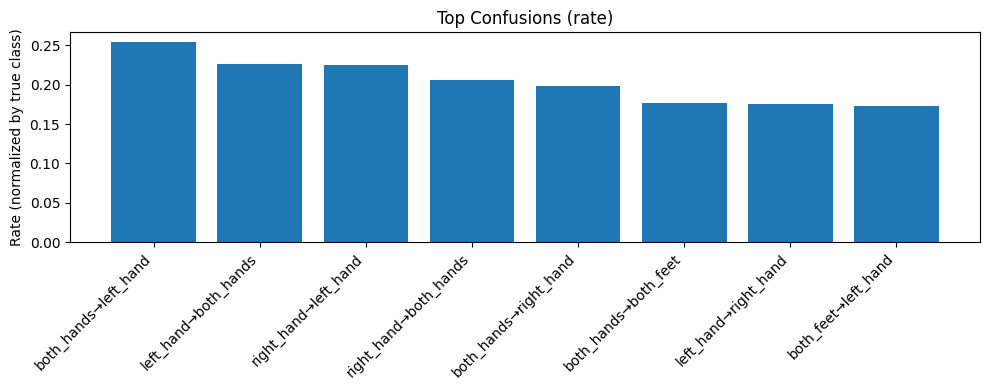

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# needs oof predictions:
# y_true = all_true, y_pred = all_pred (encoded)
cm = confusion_matrix(all_true, all_pred)
cmn = cm / (cm.sum(axis=1, keepdims=True)+1e-12)

classes = list(le.classes_)
pairs=[]
for i,t in enumerate(classes):
    for j,p in enumerate(classes):
        if i!=j:
            pairs.append((cmn[i,j], f"{t}→{p}", cm[i,j]))
pairs.sort(reverse=True)

top = pairs[:8]
plt.figure(figsize=(10,4))
plt.bar([x[1] for x in top], [x[0] for x in top])
plt.xticks(rotation=45, ha="right")
plt.title("Top Confusions (rate)")
plt.ylabel("Rate (normalized by true class)")
plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
import numpy as np
import json

BASE = Path("/content/Dataset")  # adjust if needed

# Try common places where channel names are stored
candidates = [
    BASE/"Baseline"/"ch_names.npy",
    BASE/"Baseline"/"channels.npy",
    BASE/"Baseline"/"channel_names.npy",
    BASE/"Baseline"/"ch_names.json",
    BASE/"Baseline"/"channels.json",
    BASE/"Baseline"/"README.json",
    BASE/"Baseline"/"README.md",
]

ch_names = None

for p in candidates:
    if p.exists() and p.suffix == ".npy":
        ch_names = list(np.load(p, allow_pickle=True))
        break
    if p.exists() and p.suffix == ".json":
        d = json.load(open(p))
        for k in ["ch_names","channels","channel_names"]:
            if k in d:
                ch_names = list(d[k])
                break
        if ch_names is not None:
            break

print("Found ch_names?" , ch_names is not None)
if ch_names is not None:
    print("Num channels:", len(ch_names))
    print("First 10:", ch_names[:10])

Found ch_names? False


In [ ]:
import numpy as np

# If dataset didn't give names, define neutral ones
ch_names = [f"Ch{i}" for i in range(X_clean.shape[1])]

# Pick motor-like channels by MU-band variance (fast, works well)
fs = 160
from scipy.signal import butter, sosfiltfilt

def bandpass_sos(low, high, fs, order=4):
    nyq = fs / 2
    return butter(order, [low/nyq, high/nyq], btype="bandpass", output="sos")

# Use subset for speed
Xsub = X_clean[:1000].astype(np.float32, copy=False)

sos_mu = bandpass_sos(8, 12, fs)
Xmu = sosfiltfilt(sos_mu, Xsub, axis=-1)

scores = Xmu.var(axis=-1).mean(axis=0)  # (channels,)
top3 = np.argsort(scores)[-3:][::-1]

print("✅ Data-driven Golden Channels:", [(int(i), ch_names[int(i)], float(scores[int(i)])) for i in top3])

✅ Data-driven Golden Channels: [(59, 'Ch59', 0.26399384861721026), (62, 'Ch62', 0.26184551611390805), (60, 'Ch60', 0.2602771240812601)]


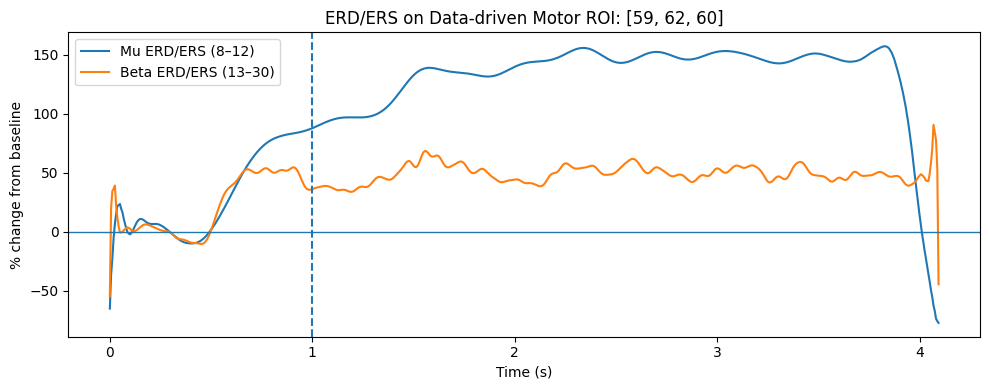

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert, sosfiltfilt

fs = 160
mu_band = (8,12)
beta_band = (13,30)

def band_envpow(X, lo, hi, fs, order=4):
    nyq = fs/2
    from scipy.signal import butter
    sos = butter(order, [lo/nyq, hi/nyq], btype="bandpass", output="sos")
    Xb = sosfiltfilt(sos, X, axis=-1)
    env = np.abs(hilbert(Xb, axis=-1))
    return env**2

idxs = list(map(int, top3))
X_roi = X_clean[:, idxs, :].mean(axis=1)  # trials x time

t = np.arange(X_roi.shape[-1]) / fs
baseline = (t >= 0.0) & (t <= 0.5)
onset_line = 1.0

def erd_curve(band):
    P = band_envpow(X_roi[:, None, :], band[0], band[1], fs).squeeze(1)  # trials x time
    base = P[:, baseline].mean(axis=1, keepdims=True)
    return 100*(P-base)/(base+1e-8)

erd_mu = erd_curve(mu_band)
erd_beta = erd_curve(beta_band)

plt.figure(figsize=(10,4))
plt.plot(t, erd_mu.mean(axis=0), label="Mu ERD/ERS (8–12)")
plt.plot(t, erd_beta.mean(axis=0), label="Beta ERD/ERS (13–30)")
plt.axvline(onset_line, linestyle="--")
plt.axhline(0, linewidth=1)
plt.title(f"ERD/ERS on Data-driven Motor ROI: {idxs}")
plt.xlabel("Time (s)")
plt.ylabel("% change from baseline")
plt.legend()
plt.tight_layout()
plt.show()

# New Section

/tmp/ipython-input-1441322299.py:36: RuntimeWarning: Mean of empty slice.
  P = P.mean(axis=1)  # avg over C3/Cz/C4
/usr/local/lib/python3.12/dist-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


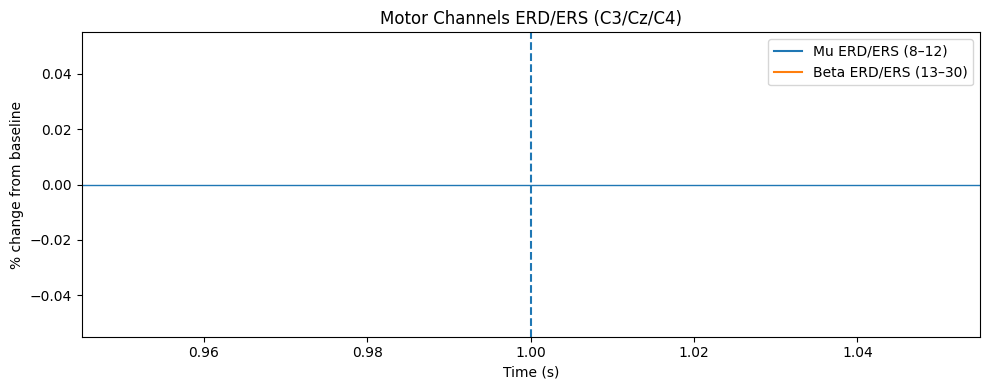

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, hilbert

fs = 160
motor_chs = ["C3","Cz","C4"]  # must exist in ch_names
mu_band = (8,12)
beta_band = (13,30)

def bp(x, lo, hi, fs, order=4):
    nyq = fs/2
    sos = butter(order, [lo/nyq, hi/nyq], btype="bandpass", output="sos")
    return sosfiltfilt(sos, x, axis=-1)

def band_envelope_power(X, lo, hi):
    Xb = bp(X, lo, hi, fs)
    env = np.abs(hilbert(Xb, axis=-1))
    return env**2

# X_clean: (trials, ch, time)
# y_all: string labels per trial OR use le.inverse_transform(y_enc)
labels = np.array(y_all, dtype=object)  # if you have y_all
# If not: labels = le.inverse_transform(y_enc)

# baseline window (edit if your task onset differs)
t = np.arange(X_clean.shape[-1]) / fs
baseline = (t >= 0.0) & (t <= 0.5)     # baseline
onset_line = 1.0                      # marker only

# channel indices
ch2i = {n:i for i,n in enumerate(ch_names)}
idxs = [ch2i[c] for c in motor_chs if c in ch2i]

def erd_curve(band):
    P = band_envelope_power(X_clean[:, idxs, :], band[0], band[1])  # trials x 3 x time
    P = P.mean(axis=1)  # avg over C3/Cz/C4
    base = P[:, baseline].mean(axis=1, keepdims=True)
    erd = 100 * (P - base) / (base + 1e-8)  # % change
    return erd

erd_mu = erd_curve(mu_band)
erd_beta = erd_curve(beta_band)

plt.figure(figsize=(10,4))
plt.plot(t, erd_mu.mean(axis=0), label="Mu ERD/ERS (8–12)")
plt.plot(t, erd_beta.mean(axis=0), label="Beta ERD/ERS (13–30)")
plt.axvline(onset_line, linestyle="--")
plt.axhline(0, linewidth=1)
plt.title("Motor Channels ERD/ERS (C3/Cz/C4)")
plt.xlabel("Time (s)")
plt.ylabel("% change from baseline")
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipython-input-2892297652.py:11: RuntimeWarning: Mean of empty slice.
  X_m = X_clean[:, idxs, :].mean(axis=1)          # trials x time


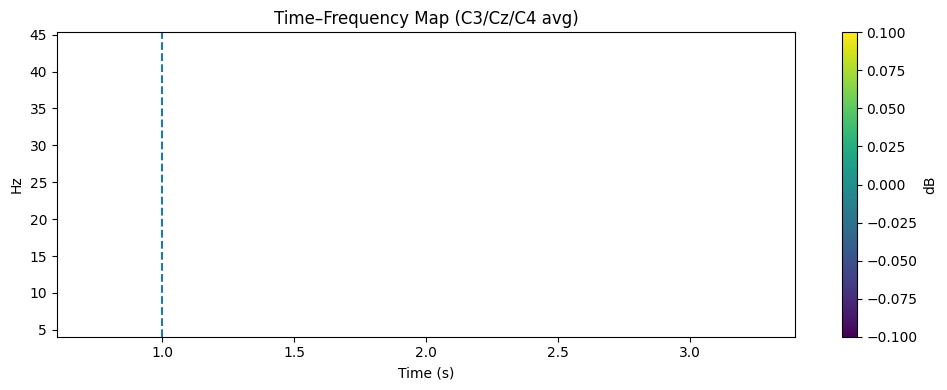

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

fs = 160
motor_chs = ["C3","Cz","C4"]
ch2i = {n:i for i,n in enumerate(ch_names)}
idxs = [ch2i[c] for c in motor_chs if c in ch2i]

# average motor channels then average trials
X_m = X_clean[:, idxs, :].mean(axis=1)          # trials x time
x = X_m.mean(axis=0)                            # time

f, tt, Sxx = spectrogram(x, fs=fs, nperseg=256, noverlap=192, scaling="density")
keep = (f>=4) & (f<=45)

plt.figure(figsize=(10,4))
plt.pcolormesh(tt, f[keep], 10*np.log10(Sxx[keep]+1e-12), shading="auto")
plt.axvline(1.0, linestyle="--")
plt.title("Time–Frequency Map (C3/Cz/C4 avg)")
plt.xlabel("Time (s)")
plt.ylabel("Hz")
plt.colorbar(label="dB")
plt.tight_layout()
plt.show()

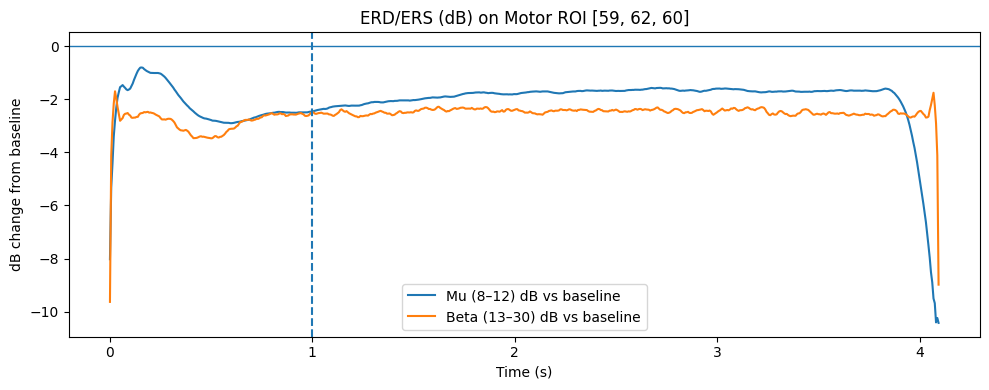

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, hilbert

fs = 160
roi = [59, 62, 60]
mu = (8,12)
beta = (13,30)

def band_env(X, lo, hi, fs):
    nyq = fs/2
    sos = butter(4, [lo/nyq, hi/nyq], btype="bandpass", output="sos")
    Xb = sosfiltfilt(sos, X, axis=-1)
    env = np.abs(hilbert(Xb, axis=-1))
    return env

X_roi = X_clean[:, roi, :].mean(axis=1)  # trials x time
t = np.arange(X_roi.shape[-1]) / fs
baseline = (t >= 0.0) & (t <= 0.5)
onset = 1.0

def erd_log(band):
    env = band_env(X_roi, band[0], band[1], fs)
    p = (env**2)  # power
    base = p[:, baseline].mean(axis=1, keepdims=True)
    return 10*np.log10((p + 1e-12)/(base + 1e-12))  # dB change

mu_db = erd_log(mu)
beta_db = erd_log(beta)

plt.figure(figsize=(10,4))
plt.plot(t, mu_db.mean(axis=0), label="Mu (8–12) dB vs baseline")
plt.plot(t, beta_db.mean(axis=0), label="Beta (13–30) dB vs baseline")
plt.axvline(onset, linestyle="--")
plt.axhline(0, linewidth=1)
plt.title(f"ERD/ERS (dB) on Motor ROI {roi}")
plt.xlabel("Time (s)")
plt.ylabel("dB change from baseline")
plt.legend()
plt.tight_layout()
plt.show()

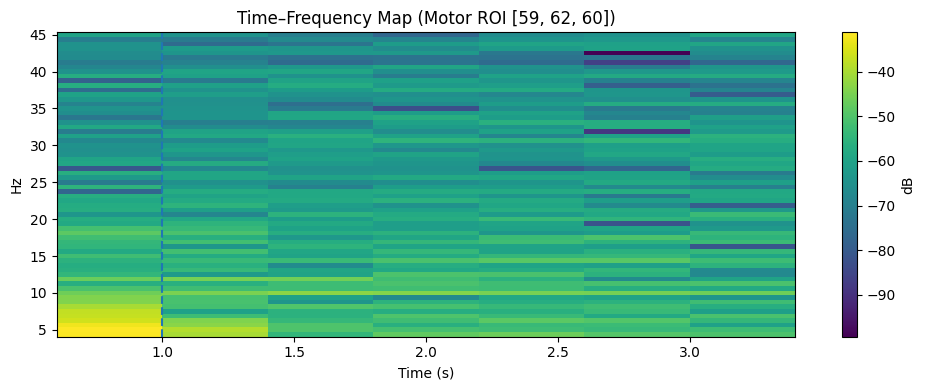

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

fs = 160
roi = [59, 62, 60]
X_roi = X_clean[:, roi, :].mean(axis=1)   # trials x time
x = X_roi.mean(axis=0)                    # time

f, tt, Sxx = spectrogram(x, fs=fs, nperseg=256, noverlap=192, scaling="density")
keep = (f>=4) & (f<=45)

plt.figure(figsize=(10,4))
plt.pcolormesh(tt, f[keep], 10*np.log10(Sxx[keep]+1e-12), shading="auto")
plt.axvline(1.0, linestyle="--")
plt.title(f"Time–Frequency Map (Motor ROI {roi})")
plt.xlabel("Time (s)")
plt.ylabel("Hz")
plt.colorbar(label="dB")
plt.tight_layout()
plt.show()

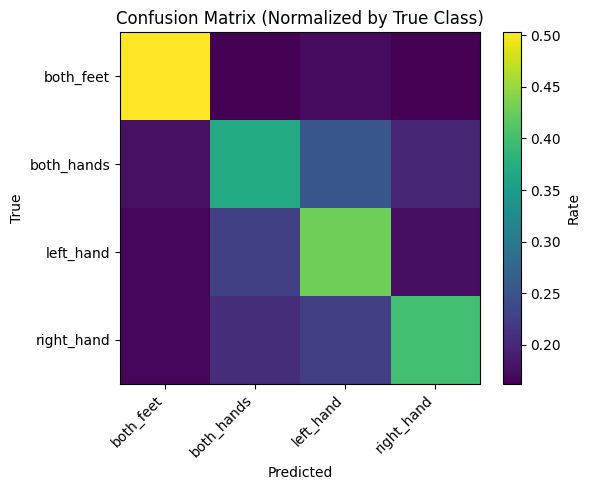

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Use your out-of-fold arrays if you have them:
# all_true, all_pred (encoded ints), le (LabelEncoder)
cm = confusion_matrix(all_true, all_pred)
cmn = cm / (cm.sum(axis=1, keepdims=True) + 1e-12)

plt.figure(figsize=(6,5))
plt.imshow(cmn, aspect="auto")
plt.xticks(range(len(le.classes_)), le.classes_, rotation=45, ha="right")
plt.yticks(range(len(le.classes_)), le.classes_)
plt.title("Confusion Matrix (Normalized by True Class)")
plt.colorbar(label="Rate")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

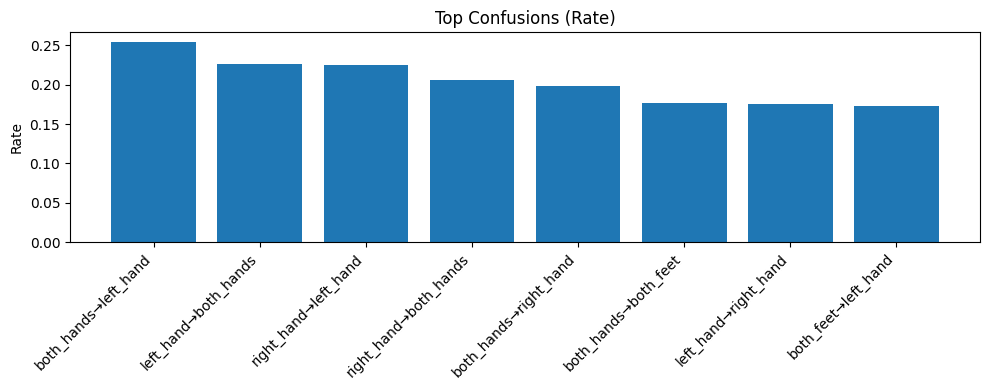

In [ ]:
pairs=[]
for i,t in enumerate(le.classes_):
    for j,p in enumerate(le.classes_):
        if i!=j:
            pairs.append((cmn[i,j], f"{t}→{p}", cm[i,j]))
pairs.sort(reverse=True)
top = pairs[:8]

plt.figure(figsize=(10,4))
plt.bar([x[1] for x in top], [x[0] for x in top])
plt.xticks(rotation=45, ha="right")
plt.title("Top Confusions (Rate)")
plt.ylabel("Rate")
plt.tight_layout()
plt.show()

Fold 1: acc=0.4208 bal_acc=0.4207
Fold 2: acc=0.4208 bal_acc=0.4209
Fold 3: acc=0.4236 bal_acc=0.4236
Fold 4: acc=0.4510 bal_acc=0.4510
Fold 5: acc=0.4115 bal_acc=0.4113

Mean acc: 0.4255612005353262 ± 0.013369472721302641
Mean bal_acc: 0.4254996667125213 ± 0.013403311211929506


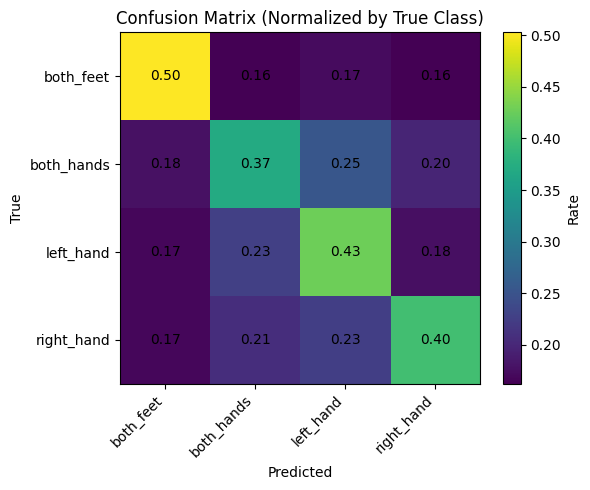


Top 6 confusions (rate, count):
0.25  both_hands→left_hand  (count=448)
0.23  left_hand→both_hands  (count=403)
0.23  right_hand→left_hand  (count=400)
0.21  right_hand→both_hands  (count=366)
0.20  both_hands→right_hand  (count=349)
0.18  both_hands→both_feet  (count=313)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score
from sklearn.linear_model import LogisticRegression
from pyriemann.tangentspace import TangentSpace

# REQUIRE: band_covs dict with keys matching band names, y_enc, g_all, le
bands = [("theta", 4, 8), ("mu", 8, 12), ("beta", 13, 30), ("gamma", 30, 45)]
band_names = [b[0] for b in bands]
classes = list(le.classes_)
n_classes = len(classes)

gkf = GroupKFold(n_splits=min(5, len(np.unique(g_all))))

all_true = y_enc.copy()
all_pred = np.zeros_like(y_enc)

accs, baccs = [], []

for fold, (tr, te) in enumerate(gkf.split(y_enc, y_enc, groups=g_all), 1):
    Xtr_feats, Xte_feats = [], []
    for name in band_names:
        ts = TangentSpace(metric="riemann")
        Xtr_feats.append(ts.fit_transform(band_covs[name][tr]))
        Xte_feats.append(ts.transform(band_covs[name][te]))
    Xtr = np.concatenate(Xtr_feats, axis=1)
    Xte = np.concatenate(Xte_feats, axis=1)

    clf = LogisticRegression(max_iter=6000, class_weight="balanced")
    clf.fit(Xtr, y_enc[tr])
    pred = clf.predict(Xte)
    all_pred[te] = pred

    accs.append(accuracy_score(y_enc[te], pred))
    baccs.append(balanced_accuracy_score(y_enc[te], pred))
    print(f"Fold {fold}: acc={accs[-1]:.4f} bal_acc={baccs[-1]:.4f}")

print("\nMean acc:", float(np.mean(accs)), "±", float(np.std(accs)))
print("Mean bal_acc:", float(np.mean(baccs)), "±", float(np.std(baccs)))

cm = confusion_matrix(all_true, all_pred, labels=np.arange(n_classes))
cmn = cm / (cm.sum(axis=1, keepdims=True) + 1e-12)

plt.figure(figsize=(6,5))
plt.imshow(cmn, aspect="auto")
plt.title("Confusion Matrix (Normalized by True Class)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(n_classes), classes, rotation=45, ha="right")
plt.yticks(range(n_classes), classes)
plt.colorbar(label="Rate")
for i in range(n_classes):
    for j in range(n_classes):
        plt.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center")
plt.tight_layout()
plt.show()

# Optional: print top confusions
pairs=[]
for i,t in enumerate(classes):
    for j,p in enumerate(classes):
        if i!=j:
            pairs.append((cmn[i,j], f"{t}→{p}", cm[i,j]))
pairs.sort(reverse=True)
print("\nTop 6 confusions (rate, count):")
for r, label, cnt in pairs[:6]:
    print(f"{r:.2f}  {label}  (count={cnt})")

In [ ]:
git init

SyntaxError: invalid syntax (ipython-input-2830201818.py, line 1)

To execute terminal commands in Google Colab, simply prefix them with an exclamation mark `!`. For example, let's list the contents of the current directory:

In [ ]:
!ls -l